# Single Crystal Data Reduction workflow by SCIPP

This notebook presents skeleton of data reduction procedure for Single Crystal for McStas h5 file of MAGiC using SCIPP. The steps are described on the corresponding [confluence page](https://confluence.ess.eu/spaces/~iuriikibalin/pages/788704198/Single-Crystal+Data+Reduction+Workflow+for+MAGiC+with+Scipp+Tasks).

In [1]:
import matplotlib.pyplot as plt
import scipp as sc
import numpy 
import os
import h5py 
import scipy
from scippneutron.conversion import graph
import matplotlib.pyplot as plt
import inspect
import plopp

In [2]:
def take_component_data_names(l_component, l_data):
    l_res = []
    for component_name in l_component:
        hh = "_".join(component_name.split("_")[1:])
        for data_name in l_data:
            if data_name.startswith(hh):
                l_res.append((component_name, data_name))
    return l_res

def read_data_component_to_dict(component, data_component):
    component_type = get_component_type(component)
    if component_type == "PSD_monitor":
        d_out = read_psd_to_dict(component, data_component)
    elif component_type == "DivPos_monitor":
        d_out = read_divpos_to_dict(component, data_component)
    elif component_type == "TOF_monitor":
        d_out = read_tof_to_dict(component, data_component)
    else: 
        d_out = read_common_to_dict(component, data_component)
    return d_out


def read_psd_to_dict(component, data_component):
    d_out = read_common_to_dict(component, data_component)
    d_out["X_position"] = data_component["X_position__cm_"][()]
    d_out["Y_position"] = data_component["Y_position__cm_"][()]
    return d_out


def read_divpos_to_dict(component, data_component):
    d_out = read_common_to_dict(component, data_component)
    d_out["divergence"] = data_component["divergence__deg_"][()]
    d_out["pos"] = data_component["pos__m_"][()]
    return d_out
        

def read_tof_to_dict(component, data_component):
    d_out = read_common_to_dict(component, data_component)
    d_out["time_of_flight"] = data_component["Time_of_flight___gms_"][()]
    return d_out
        
def read_common_to_dict(component, data_component):
    values = data_component["data"][()]
    errors = data_component["errors"][()]
    ncount = data_component["ncount"][()]
    d_component = get_type_position_rotation_of_component(component)
    d_out = {
        "data": values,
        "errors": errors,
        "ncount": ncount,
    }
    d_out.update(d_component)
    return d_out

def get_component_type(component):
    component_type = component["Component_type"][()][0].decode("ascii")
    return component_type

def get_type_position_rotation_of_component(component):
    component_type = get_component_type(component)
    position = component["Position"][()]
    rotation = component["Rotation"][()]
    d_out = {
        "component_type": component_type,
        "position": position,
        "rotation": rotation,
    }
    return d_out
    


In [3]:
def plot_data(d_data):
    if d_data["component_type"] == "PSD_monitor":
        fig = display_psd(d_data)
    elif d_data["component_type"] == "TOF_monitor":
        fig = display_tof(d_data)
    elif d_data["component_type"] == "DivPos_monitor":
        fig = display_divpos(d_data)
    else:
        fig = get_figure_common(d_data)
    return fig

def get_figure_common(d_data):
    fig = plt.figure()
    ax = fig.add_axes((0,0,1,1))
    ncount = int(d_data["ncount"].sum())
    ax.set_title(d_data["component_name"] + f" at ({d_data['position'][0]:.3f} {d_data['position'][1]:.3f} {d_data['position'][2]:.3f})m Ncount {ncount:}")
    return fig

def display_psd(d_data):
    fig = get_figure_common(d_data)
    ax = fig.axes[0]
    np_x, np_y = d_data["X_position"], d_data["Y_position"]
    pos = ax.imshow(d_data["data"].transpose(), origin="lower", extent=(np_x.min(), np_x.max(), np_y.min(), np_y.max()),vmin=0, vmax=1e7)
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel("X position (cm)")
    ax.set_ylabel("Y position (cm)")
    return fig

def display_tof(d_data):
    fig = get_figure_common(d_data)
    ax = fig.axes[0]
    np_x, np_y = d_data["time_of_flight"], d_data["data"]
    ax.plot(np_x, np_y,"ko")
    ax.plot(np_x, np_y,"k-", alpha=0.3)
    ax.set_xlabel("Time of Flight (micro seconds)")
    ax.set_ylabel("Intensity (arb. units)")
    return fig

def display_divpos(d_data):
    fig = get_figure_common(d_data)
    ax = fig.axes[0]
    np_x, np_y = d_data["pos"], d_data["divergence"]
    pos = ax.imshow(d_data["data"].transpose(), origin="lower", extent=(np_x.min(), np_x.max(), np_y.min(), np_y.max()), aspect="auto")
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel("Position (cm)")
    ax.set_ylabel("Divergence (deg.)")
    return fig

In [4]:
def read_h5_to_dict(f_nexus):
    d_out = {}
    delta_L_deafault = sc.scalar(0., unit='m')
    delta_t_default = sc.scalar(3., unit='ms').to(unit="s", copy=False)
    with h5py.File(f_nexus) as fid:
        components = fid["entry1"]["instrument"]["components"] 
        l_key_sample = [hh for hh in components.keys() if "_sampleMantid" in hh]
        l_key_source = [hh for hh in components.keys() if "_sourceMantid" in hh]
        l_key_detector = [hh for hh in components.keys() if "_nD_Mantid_" in hh]

        l_components = components.keys()

        sample = components[l_key_sample[0]]
        sample_position = sample["Position"][()]

        detector = components[l_key_detector[0]]
        detector_position = detector["Position"][()]
        detector_rotation = detector["Rotation"][()]
        detector_radius = float(detector["Geometry"].attrs["radius"])

        data = fid["entry1"]["data"] # 
        l_data = data.keys()
        l_component_data_names = take_component_data_names(l_components, l_data)
        for component_name, data_name in l_component_data_names:
            component = components[component_name]
            data_component = data[data_name]
        
            d_out[data_name] = read_data_component_to_dict(component, data_component)
            d_out[data_name]["component_name"] = component_name
        d_components = {}
        for component_name in l_components:
            component = components[component_name]
            d_component = get_type_position_rotation_of_component(component)
            component_name_short = "_".join(component_name.split("_")[1:])
            d_components[component_name_short] = d_component
        d_out["components"] = d_components

        simulation_param = fid["entry1"]["simulation"]["Param"]
        sample_omega = float(simulation_param["sample_rotation_y"][()][0].decode("ascii"))
        neutron_up = simulation_param["isFlip"][()]
        
        if "bank00_events_dat_list_p_th_y_n_id_t" in l_data:
            data_events = data["bank00_events_dat_list_p_th_y_n_id_t"]["events"][()]
            da = sc.DataArray(
                data=sc.array(
                    dims=['event'], values=data_events[:, 0], variances=(data_events[:, 0]**2)
                ),
            coords={
                'detector_radius': sc.scalar(detector_radius, unit='m'),
                'delta_L': delta_L_deafault,
                'delta_t': delta_t_default,
                'source_position': sc.vector(value=d_components['arm_w6']["position"], unit='m'),
                'tp_position': sc.vector(value=d_components["arm_egs2"]["position"],unit="m"),
                'ideal_sample_position': sc.vector(sample_position, unit='m'),
                'sample_offset': sc.vector([0., 0., 0.], unit='m'),
                'detector_position': sc.vector(detector_position, unit='m'),
                'detector_pixel_gamma_local': sc.array(dims=['event'], values=data_events[:,1], unit='deg').to(unit="rad", copy=False),
                'detector_pixel_vertical_local': sc.array(dims=['event'], values=data_events[:,2], unit='m'),
                'toa': sc.array(dims=['event'], values=data_events[:, 5], unit='s'),
                'sample_omega': sc.scalar(sample_omega, unit='deg.').to(unit="rad", copy=False),
                'sample_chi': sc.scalar(0., unit='deg.').to(unit="rad", copy=False),
                'sample_phi': sc.scalar(0., unit='deg.').to(unit="rad", copy=False),
            }
            )
            d_out["data_event"] = da
        if "tof_egs2_1_plot" in d_out.keys(): # cave monitor
            data_monitor = d_out["tof_egs2_1_plot"]
            da = sc.DataArray(
                data=sc.array(
                    dims=['counts'], values=data_monitor['data'], variances=(data_monitor['errors']**2)
                ),
            coords={
                'source_position': sc.vector(value=d_components['arm_w6']["position"], unit='m'),
                'tp_position': sc.vector(value=d_components["arm_egs2"]["position"],unit="m"),
                'cave_monitor_position': sc.vector(value=d_components["tof_egs2_1"]["position"],unit="m"),
                'delta_L': delta_L_deafault,
                'delta_t': delta_t_default,
                'toa': sc.array(dims=['counts'], values=data_monitor["time_of_flight"], unit='micros').to(unit="s", copy=False),
            }
            )
            d_out["data_cave_monitor"] = da           
    return d_out

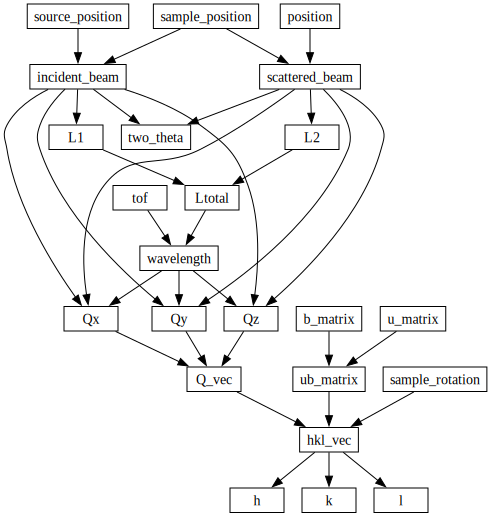

In [5]:
scipp_graph = {**graph.beamline.beamline(scatter=True), **graph.tof.elastic_hkl(start='tof')}
sc.show_graph(scipp_graph, simplified=True)

In [6]:
def get_sc_rotation_matrix(r_matrix):
    quternion_r_matrix = scipy.spatial.transform.Rotation.from_matrix(r_matrix).as_quat()
    r_out = sc.spatial.rotation(value=quternion_r_matrix / numpy.linalg.norm(quternion_r_matrix))
    return r_out 
    
def calc_incident_beam_magic(source_position, tp_position, sample_position):
    tp = tp_position.to(unit='m', copy=False)
    v1 = sample_position.to(unit='m', copy=False) - tp
    v2 = tp - source_position.to(unit='m', copy=False)
    e1 = v1/sc.norm(v1)
    incident_beam = v1 + e1 * sc.norm(v2)
    return incident_beam

def calc_position(detector_position, detector_event_position_local):
    position = detector_position.to(unit='m', copy=False) + detector_event_position_local.to(unit='m', copy=False)
    return position

def calc_detector_event_position_local(detector_pixel_gamma_local, detector_pixel_vertical_local, detector_radius):
    dr = detector_radius.to(unit='m', copy=False)
    dy = detector_pixel_vertical_local.to(unit='m', copy=False)
    dx = dr * sc.sin(detector_pixel_gamma_local.to(unit="deg", copy=False))
    dz = dr * sc.cos(detector_pixel_gamma_local.to(unit="deg", copy=False))
    detector_event_position_local = sc.spatial.as_vectors(dx, dy, dz)
    return detector_event_position_local

def calc_tof(toa, delta_t=sc.scalar(value=3, unit="ms")):
    tof = toa.to(unit='s', copy=False) - delta_t.to(unit='s', copy=False)
    return tof

def calc_Ltotal(L1, L2, delta_L=sc.scalar(value=0, unit="m")):
    Ltotal = L1.to(unit='m', copy=False) + L2.to(unit='m', copy=False) - delta_L.to(unit='m', copy=False)
    return Ltotal

def calc_sample_rotation(sample_omega, sample_chi, sample_phi):
    zero_o = sc.sin(sc.zeros_like(sample_omega))
    one_o = sc.cos(sc.zeros_like(sample_omega))
    m_omega = [
        [sc.cos(sample_omega), zero_o, sc.sin(sample_omega)],
        [zero_o, one_o, zero_o],
        [-sc.sin(sample_omega), zero_o, sc.cos(sample_omega)],
    ]
    zero_c = sc.sin(sc.zeros_like(sample_chi))
    one_c = sc.cos(sc.zeros_like(sample_chi))
    m_chi = [
        [sc.cos(sample_chi), -sc.sin(sample_chi), zero_c],
        [sc.sin(sample_chi), sc.cos(sample_chi), zero_c],
        [zero_c, zero_c, one_c],
    ]

    zero_p = sc.sin(sc.zeros_like(sample_phi))
    one_p = sc.cos(sc.zeros_like(sample_phi))
    m_phi = [
        [sc.cos(sample_phi), zero_p, sc.sin(sample_phi)],
        [zero_p, one_p, zero_p],
        [-sc.sin(sample_phi), zero_p, sc.cos(sample_phi)],
    ]
    rm_o = get_sc_rotation_matrix(m_omega)
    rm_c = get_sc_rotation_matrix(m_chi)
    rm_p = get_sc_rotation_matrix(m_phi)
    sample_rotation = rm_o * rm_c * rm_p
    return sample_rotation

def calc_orientation_matrix(euler_alpha, euler_beta, euler_gamma, ):
    ca, cb, cg = sc.cos(euler_alpha), sc.cos(euler_beta), sc.cos(euler_gamma)
    sa, sb, sg = sc.sin(euler_alpha), sc.sin(euler_beta), sc.sin(euler_gamma)
    m_m = [
        [ca*cb, ca*sb*sg-sa*cg, ca*sb*cg+sa*sg],
        [sa*cb, sa*sb*sg+ca*cg, sa*sb*cg-ca*sg],
        [-sb, cb*sg, cb*cg],
    ]
    orientation_matrix = get_sc_rotation_matrix(m_m)
    return orientation_matrix

def _calc_cell_phi(cell_alpha, cell_beta, cell_gamma):
    ca, cb, cg = sc.cos(cell_alpha), sc.cos(cell_beta), sc.cos(cell_gamma)
    cell_phi = sc.sqrt(1. - ca*ca - cb*cb - cg*cg + 2 * ca * cb * cg)
    return cell_phi

def calc_cell_volume(cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma):
    cell_phi = _calc_cell_phi(cell_alpha, cell_beta, cell_gamma)
    cell_volume = cell_a.to(unit="angstrom") * cell_b.to(unit="angstrom") * cell_c.to(unit="angstrom") * cell_phi
    return cell_volume

def calc_b_matrix(cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma):
    cell_phi = _calc_cell_phi(cell_alpha, cell_beta, cell_gamma)
    a, b, c = cell_a.to(unit="angstrom").value, cell_b.to(unit="angstrom").value, cell_c.to(unit="angstrom").value
    b_11 = sc.sin(cell_alpha)/(a*cell_phi)
    b_12 = (sc.cos(cell_alpha)*sc.cos(cell_beta)-sc.cos(cell_gamma))/(b*cell_phi*sc.sin(cell_alpha))
    b_13 = (sc.cos(cell_alpha)*sc.cos(cell_gamma)-sc.cos(cell_beta))/(c*cell_phi*sc.sin(cell_alpha))
    b_22 = 1/(b*sc.sin(cell_alpha))
    b_23 = -sc.cos(cell_alpha)/(c*sc.sin(cell_alpha))
    b_33 = 1/c
    zero = 0.
    b_matrix = sc.spatial.linear_transform(
        value=[
            [b_11, b_12, b_13],
            [zero, b_22, b_23],
            [zero, zero, b_33],
        ],
        unit='1/angstrom',
    )
    return b_matrix

def calc_h_reduced(h):
    h_reduced = h%1
    h_reduced.values[h_reduced.values > 0.5] -= 1.
    return h_reduced

def calc_k_reduced(k):
    k_reduced = calc_h_reduced(k)
    return k_reduced

def calc_l_reduced(l):
    l_reduced = calc_h_reduced(l)
    return l_reduced

def Q_vec_rot_from_elastic_Q_vec(*, Q_vec: sc.Variable, sample_rotation: sc.Variable) -> sc.Variable:
    return (sc.spatial.inv(sample_rotation) * Q_vec)

def hkl_vec_from_elastic_Q_vec_rot(*, Q_vec_rot: sc.Variable, ub_matrix: sc.Variable) -> sc.Variable:
    return (sc.spatial.inv(ub_matrix) * Q_vec_rot) / (2 * numpy.pi)

def Q_vec_rot_from_elastic_hkl_vec(*, hkl_vec: sc.Variable, ub_matrix: sc.Variable) -> sc.Variable:
    return (ub_matrix * hkl_vec * 2 * numpy.pi)



def calc_sample_position(ideal_sample_position, sample_offset):
    sample_position = ideal_sample_position.to(unit='m', copy=False) + sample_offset.to(unit='m', copy=False)
    return sample_position

def calc_unit_cell_parameters_by_b_matrix(b_matrix):
    np_b = b_matrix.to(unit="1/Angstrom").values
    abc_inv = numpy.sqrt(numpy.square(np_b).sum(axis=0))
    cos_abg_inv = (numpy.roll(np_b,shift=-1,axis=1)*numpy.roll(np_b,shift=-2,axis=1)).sum(axis=0)/(numpy.roll(abc_inv, shift=-1,axis=0)*numpy.roll(abc_inv, shift=-2,axis=0))
    sin_abg_inv = numpy.sqrt(1.-numpy.square(cos_abg_inv))
    phi_inv = numpy.sqrt(1.-numpy.square(cos_abg_inv).sum()+2.*cos_abg_inv.prod())
    vol_inv = abc_inv.prod()*phi_inv
    vol = 1./vol_inv
    abc = numpy.roll(abc_inv, shift=-1,axis=0)*numpy.roll(abc_inv, shift=-2,axis=0)*sin_abg_inv/vol_inv
    sin_abg = phi_inv/(numpy.roll(sin_abg_inv, shift=-1,axis=0)*numpy.roll(sin_abg_inv, shift=-2,axis=0))
    abg=numpy.degrees(numpy.asin(sin_abg))
    cell_a = sc.scalar(abc[0], unit="Angstrom")
    cell_b = sc.scalar(abc[1], unit="Angstrom")
    cell_c = sc.scalar(abc[2], unit="Angstrom")
    cell_alpha = sc.scalar(abg[0], unit="deg")
    cell_beta = sc.scalar(abg[1], unit="deg")
    cell_gamma = sc.scalar(abg[2], unit="deg")
    return (cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma)

def calc_norm_q(Q_vec):
    return sc.norm(Q_vec)


graph_qvec = {
    "incident_beam": calc_incident_beam_magic,
    "position": calc_position,
    "detector_event_position_local": calc_detector_event_position_local,
    "tof": calc_tof,
    "Ltotal": calc_Ltotal,
    "sample_rotation": calc_sample_rotation,
    "Q_vec_rot": Q_vec_rot_from_elastic_Q_vec,
    "L1": scipp_graph["L1"],
    "L2": scipp_graph["L2"],
    "scattered_beam": scipp_graph["scattered_beam"],
    "Q_vec": scipp_graph["Q_vec"],
    "two_theta": scipp_graph["two_theta"],
    "norm_Q": calc_norm_q,
    "wavelength": scipp_graph["wavelength"],
    ("Qx","Qy","Qz"): scipp_graph[("Qx","Qy","Qz")],
    "sample_position": calc_sample_position,
}
graph_hkl = {

    "cell_volume": calc_cell_volume,
    "b_matrix": calc_b_matrix,
    "u_matrix": calc_orientation_matrix,
    "h_reduced": calc_h_reduced,
    "k_reduced": calc_k_reduced,
    "l_reduced": calc_l_reduced,
    "hkl_vec": hkl_vec_from_elastic_Q_vec_rot,
    "ub_matrix": scipp_graph["ub_matrix"],
    ("h","k","l"): scipp_graph[("h","k","l")],
}

graph_hkl_inv = {
    "Q_vec_rot": Q_vec_rot_from_elastic_hkl_vec,
    "b_matrix": graph_hkl["b_matrix"],
    "u_matrix": graph_hkl["u_matrix"],
    "ub_matrix": graph_hkl["ub_matrix"],
}

graph_ub_inv = {
    ("cell_a","cell_b","cell_c","cell_alpha","cell_beta","cell_gamma"): calc_unit_cell_parameters_by_b_matrix,
}

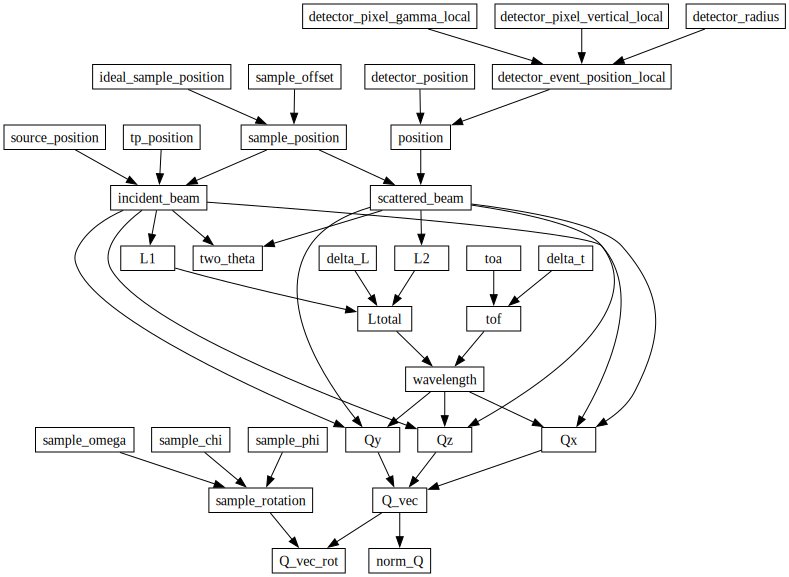

In [7]:
sc.show_graph(graph_qvec, simplified=True)

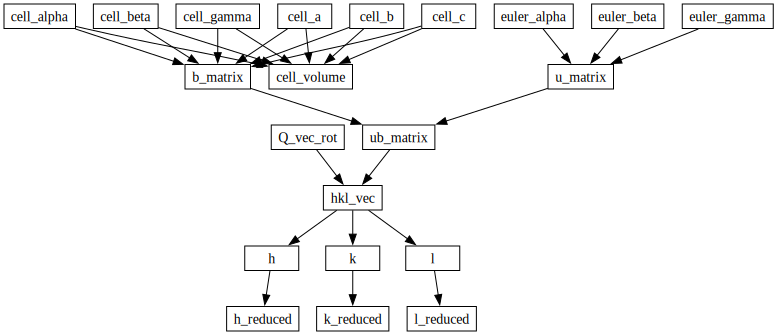

In [8]:
sc.show_graph(graph_hkl, simplified=True)

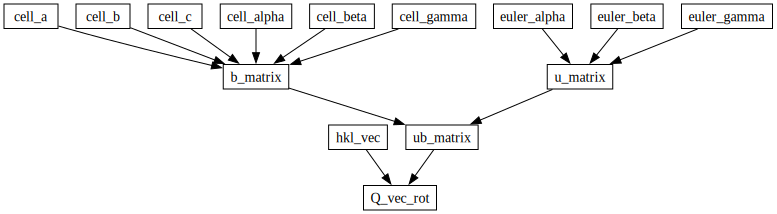

In [9]:
sc.show_graph(graph_hkl_inv, simplified=True)

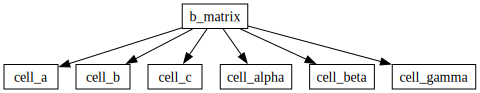

In [10]:
sc.show_graph(graph_ub_inv, simplified=True)


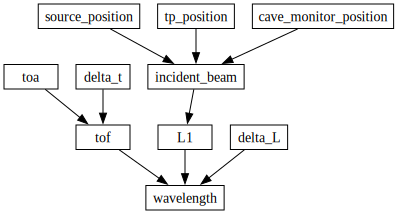

In [11]:
def calc_incident_beam_cave_monitor(source_position, tp_position, cave_monitor_position):
    incident_beam = graph_qvec["incident_beam"](source_position, tp_position, cave_monitor_position)
    return incident_beam

def calc_wavelength(L1, delta_L, tof):
    Ltotal = L1.to(unit='m', copy=False) - delta_L.to(unit='m', copy=False)
    wavelength = graph_qvec["wavelength"](Ltotal=Ltotal, tof=tof)
    return wavelength

graph_cave_monitor = {
    "tof": graph_qvec["tof"],
    "L1": graph_qvec["L1"],
    "incident_beam": calc_incident_beam_cave_monitor,
    "wavelength": calc_wavelength,
}
sc.show_graph(graph_cave_monitor, simplified=True)

# Preprocessing

## Load Event Data

Data is loaded from Mstas simulation file

In [12]:
f_nexus = r"/Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_27/mccode.h5"
f_nexus = r"/Users/iuriikibalin/Documents/files/ESS/McStas/scipp_magic/mcstas_simulations/mccode.h5"
d_out = read_h5_to_dict(f_nexus)
d_out.keys()

dict_keys(['tof_chop_1_plot', 'tof_w6_1_plot', 'tof_egs2_1_plot', 'psd_sample_pos_1_plot', 'divpos_sample_pos_1_plot', 'components', 'data_event', 'data_cave_monitor'])

The simulation file contains information about event data on the detector and information from the cave monitor

In [13]:
data_cave_monitor = d_out["data_cave_monitor"]
data_event = d_out["data_event"]

In [14]:
"""
fig = plot_data(d_out["tof_chop_1_plot"])
fig = plot_data(d_out["tof_w6_1_plot"])
fig = plot_data(d_out["tof_egs2_1_plot"])
fig = plot_data(d_out["psd_sample_pos_1_plot"])
fig = plot_data(d_out["divpos_sample_pos_1_plot"])
"""
data_event

<scipp.DataArray>
Dimensions: Sizes[event:2015340, ]
Coordinates:
* delta_L                   float64              [m]  ()  0
* delta_t                   float64              [s]  ()  0.003
* detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
* detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
* detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
* detector_radius           float64              [m]  ()  1
* ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
* sample_chi                float64            [rad]  ()  0
* sample_offset             vector3              [m]  ()  (0, 0, 0)
* sample_omega              float64            [rad]  ()  0
* sample_phi                float64            [rad]  ()  0
* source_position           vector3              [m]  ()  (-0.034, 0, 0)
* toa                       float64              [s]  (event)  [0.0690874, 0.0562372, ..., 0.0565717, 0.0565965]
* tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
Data:
                            float64  [dimensionless]  (event)  [0.0172735, 0.00127292, ..., 9.18242e-11, 1.25802e-13]  [0.000298374, 1.62032e-06, ..., 8.43169e-21, 1.58262e-26]

**Laue pattern (integrated over time) on the detector**

In [15]:
range_gamma_local = data_event.coords["detector_pixel_gamma_local"].max() - data_event.coords["detector_pixel_gamma_local"].min()
range_vertical_local = data_event.coords["detector_pixel_vertical_local"].max() - data_event.coords["detector_pixel_vertical_local"].min()
flag_1 = data_event.coords["detector_pixel_gamma_local"] > data_event.coords["detector_pixel_gamma_local"].min() + 0.02 * range_gamma_local
flag_2 = data_event.coords["detector_pixel_gamma_local"] < data_event.coords["detector_pixel_gamma_local"].max() - 0.02 * range_gamma_local
flag_3 = data_event.coords["detector_pixel_vertical_local"] > data_event.coords["detector_pixel_vertical_local"].min() + 0.02 * range_vertical_local
flag_4 = data_event.coords["detector_pixel_vertical_local"] < data_event.coords["detector_pixel_vertical_local"].max() - 0.02 * range_vertical_local
data_event.masks['detector_border'] = sc.logical_not(sc.logical_and(flag_1, sc.logical_and(flag_2, sc.logical_and(flag_3, flag_4))))

In [16]:
data_event = data_event.transform_coords(("position",), graph=graph_qvec)
plopp.scatter3d(data_event, pos='position', cbar=True, size=0.0001, opacity=0.5)

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

**Signal from cave monitor**

TODO: here the step in time is 1ms, modify it to 10 microseconds

In [17]:
data_cave_monitor

<scipp.DataArray>
Dimensions: Sizes[counts:101, ]
Coordinates:
* cave_monitor_position     vector3              [m]  ()  (-0.034, -0.674198, 152.955)
* delta_L                   float64              [m]  ()  0
* delta_t                   float64              [s]  ()  0.003
* source_position           vector3              [m]  ()  (-0.034, 0, 0)
* toa                       float64              [s]  (counts)  [0.000693069, 0.00207921, ..., 0.137921, 0.139307]
* tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
Data:
                            float64  [dimensionless]  (counts)  [0, 0, ..., 0, 0]  [0, 0, ..., 0, 0]

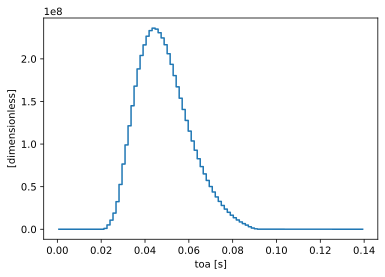

In [18]:
data_cave_monitor.hist(toa=101).plot()

## Transform to Q-space

In [19]:
da_q_event = data_event.transform_coords(("Q_vec_rot","norm_Q", "two_theta"), graph=graph_qvec)
da_q_event

<scipp.DataArray>
Dimensions: Sizes[event:2015340, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00573, ..., 1.0211, 1.09208]
  Ltotal                    float64              [m]  (event)  [155.5, 155.506, ..., 155.521, 155.592]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
  Qx                        float64           [1/Å]  (event)  [-3.73697, -4.61269, ..., -4.13153, -4.13061]
  Qy                        float64           [1/Å]  (event)  [0.00973955, 0.494463, ..., 0.932518, 1.85303]
  Qz                        float64           [1/Å]  (event)  [3.71059, 4.67838, ..., 2.78865, 3.7371]
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
* norm_Q                    float64           [1/Å]  (event)  [5.26626, 6.58852, ..., 5.07106, 5.8704]
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965964, -0.78139, 154.489), ..., (0.880968, -0.880713, 154.901), (0.944357, -1.1131, 154.704)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  toa                       float64              [s]  (event)  [0.0690874, 0.0562372, ..., 0.0565717, 0.0565965]
  tof                       float64              [s]  (event)  [0.0660874, 0.0532372, ..., 0.0535717, 0.0535965]
  tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
* two_theta                 float64            [rad]  (event)  [1.56371, 1.57922, ..., 1.16452, 1.38016]
  wavelength                float64             [Å]  (event)  [1.68131, 1.35434, ..., 1.36272, 1.36273]
Data:
                            float64  [dimensionless]  (event)  [0.0172735, 0.00127292, ..., 9.18242e-11, 1.25802e-13]  [0.000298374, 1.62032e-06, ..., 8.43169e-21, 1.58262e-26]
Masks:
  detector_border              bool        <no unit>  (event)  [False, False, ..., False, False]

## Calibration: normalization per incident spectra estimated by cave monitor

The diffracted signal is normalised per incident spectrum estimated by a monitor in a cave, and the events with wavelength outside the specified minimal and maximal wavelength range are cut off.

In [20]:
da_cm = data_cave_monitor.transform_coords(("wavelength",), graph=graph_cave_monitor)
da_cm
# Check overlqpping wavelength

<scipp.DataArray>
Dimensions: Sizes[counts:101, ]
Coordinates:
  L1                        float64              [m]  ()  152.958
  cave_monitor_position     vector3              [m]  ()  (-0.034, -0.674198, 152.955)
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  incident_beam             vector3              [m]  ()  (0, 0, 152.958)
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  toa                       float64              [s]  (counts)  [0.000693069, 0.00207921, ..., 0.137921, 0.139307]
  tof                       float64              [s]  (counts)  [-0.00230693, -0.000920792, ..., 0.134921, 0.136307]
  tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
* wavelength                float64             [Å]  (counts)  [-0.0596653, -0.0238149, ..., 3.48953, 3.52538]
Data:
                            float64  [dimensionless]  (counts)  [0, 0, ..., 0, 0]  [0, 0, ..., 0, 0]

In [ ]:
# TODO: It should be normalized per one and time 
# TODO: It should be an option load normalization from external file as monitor is not quite stable

def normalize_per_cave_monitor(da_q_event, da_cm, factor=0.1):
    da_cm.masks["counts"] = sc.logical_not(da_cm.data > factor*da_cm.data.max())
    cm_wavelength = da_cm.coords['wavelength'][sc.logical_not(da_cm.masks["counts"])]
    cm_weight = da_cm.data[sc.logical_not(da_cm.masks["counts"])]
    cm_weight = cm_weight/cm_weight.max().values
    cm_wavelength_min = cm_wavelength.min()
    cm_wavelength_max = cm_wavelength.max()
    print(f"Minimal wavelength is {cm_wavelength_min.value:7.5f} {cm_wavelength_min.unit}")
    print(f"Maximal wavelength is {cm_wavelength_max.value:7.5f} {cm_wavelength_max.unit}")

    flag = sc.logical_and(da_q_event.coords['wavelength'] >  cm_wavelength_min, da_q_event.coords['wavelength'] < cm_wavelength_max)
    da_q_event_reduced = da_q_event[flag]
    coeff = numpy.interp(da_q_event_reduced.coords['wavelength'].values, cm_wavelength.values, cm_weight.values)
    da_q_event_reduced.data  = da_q_event_reduced.data /sc.array(dims=("event",), values=coeff, unit=da_q_event_reduced.data.unit)
    return da_q_event_reduced

In [22]:
da_q_event_normalized = normalize_per_cave_monitor(da_q_event, da_cm, factor=0.1)
da_q_event_normalized

Minimal wavelength is 0.62149 Å
Maximal wavelength is 1.91211 Å


<scipp.DataArray>
Dimensions: Sizes[event:1744654, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00573, ..., 1.0211, 1.09208]
  Ltotal                    float64              [m]  (event)  [155.5, 155.506, ..., 155.521, 155.592]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
  Qx                        float64           [1/Å]  (event)  [-3.73697, -4.61269, ..., -4.13153, -4.13061]
  Qy                        float64           [1/Å]  (event)  [0.00973955, 0.494463, ..., 0.932518, 1.85303]
  Qz                        float64           [1/Å]  (event)  [3.71059, 4.67838, ..., 2.78865, 3.7371]
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
* norm_Q                    float64           [1/Å]  (event)  [5.26626, 6.58852, ..., 5.07106, 5.8704]
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965964, -0.78139, 154.489), ..., (0.880968, -0.880713, 154.901), (0.944357, -1.1131, 154.704)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  toa                       float64              [s]  (event)  [0.0690874, 0.0562372, ..., 0.0565717, 0.0565965]
  tof                       float64              [s]  (event)  [0.0660874, 0.0532372, ..., 0.0535717, 0.0535965]
  tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
* two_theta                 float64            [rad]  (event)  [1.56371, 1.57922, ..., 1.16452, 1.38016]
  wavelength                float64             [Å]  (event)  [1.68131, 1.35434, ..., 1.36272, 1.36273]
Data:
                            float64  [dimensionless]  (event)  [0.0672322, 0.00186339, ..., 1.37066e-10, 1.8779e-13]  [0.00452017, 3.47223e-06, ..., 1.87872e-20, 3.5265e-26]
Masks:
  detector_border              bool        <no unit>  (event)  [False, False, ..., False, False]

# Peak finding

The peaks are identified from event-mode data by applying statistical clustering techniques. Searching is performed for event normalized data.

**TODO:**
 - Sigmas for found peaks in Q space
 - merge radius should be dependent form the resolution of the diffractometer.
 - Basin radius should be dependent from expected distances between two closest peaks.

In [23]:
from scipy.spatial import cKDTree

def adaptive_bandwidth(q):
    # Replace with your MAGiC/ESS resolution model
    Q = numpy.linalg.norm(q)
    return 0.01 + 0.02 * Q


class MeanShiftNeighborSearch:
    def __init__(self, q_events):
        self.q_events = numpy.asarray(q_events)
        self.tree = cKDTree(self.q_events)

    def neighbors_within(self, x, radius):
        idx = self.tree.query_ball_point(x, radius)
        return numpy.asarray(idx, dtype=int)


def mean_shift_single_accel(
    q_events,
    weights,
    start,
    max_iter=200,
    tol=1e-6,
    radius_factor=3.0,
    neighbor_search=None,
):
    """
    One adaptive mean-shift run using KD-tree neighbor search.
    """
    if neighbor_search is None:
        neighbor_search = MeanShiftNeighborSearch(q_events)

    x = start.copy()
    for _ in range(max_iter):
        h = adaptive_bandwidth(x)
        radius = radius_factor * h

        idx = neighbor_search.neighbors_within(x, radius)
        if idx.size == 0:
            break

        q_loc = q_events[idx]
        w_loc = weights[idx]

        diff = q_loc - x
        dist2 = numpy.sum(diff**2, axis=1)

        k = numpy.exp(-dist2 / (2 * h * h))
        w = w_loc * k
        denom = numpy.sum(w)
        if denom == 0:
            break

        x_new = numpy.sum(q_loc * w[:, None], axis=0) / denom
        if numpy.linalg.norm(x_new - x) < tol:
            return x_new

        x = x_new

    return x
def _cluster_modes(modes, merge_radius):
    clusters = []
    for m in modes:
        placed = False
        for c in clusters:
            if numpy.linalg.norm(m - c) < merge_radius:
                c[:] = 0.5 * (c + m)
                placed = True
                break
        if not placed:
            clusters.append(m.copy())
    return numpy.array(clusters)


def _compute_peak_intensity(q_events, weights, peak, radius, neighbor_search):
    idx = neighbor_search.neighbors_within(peak, radius)
    if idx.size == 0:
        return 0.0
    return numpy.sum(weights[idx])


def find_multiple_peaks_accel(
    events_coords,
    events_weight=None,
    # max_peaks=10,
    merge_radius=0.05,
    basin_radius=0.1,
    max_seeds=5000,
    random_state=None,
    radius_factor=3.0,
):
    """
    Multi-peak adaptive mean-shift with KD-tree acceleration.
    """
    q_events = events_coords.values


    q_events = numpy.asarray(q_events)
    N, d = q_events.shape

    if events_weight is None:
        weights = numpy.ones(N, dtype=float)
    else:
        weights = numpy.asarray(events_weight.values, dtype=float)


    rng = numpy.random.default_rng(random_state)
    if N > max_seeds:
        idx_seeds = rng.choice(N, size=max_seeds, replace=False)
    else:
        idx_seeds = numpy.arange(N)

    neighbor_search = MeanShiftNeighborSearch(q_events)

    modes = []
    for i in idx_seeds:
        m = mean_shift_single_accel(
            q_events,
            weights,
            start=q_events[i],
            neighbor_search=neighbor_search,
            radius_factor=radius_factor,
        )
        modes.append(m)
    modes = numpy.array(modes)

    unique_peaks = _cluster_modes(modes, merge_radius)

    intensities = numpy.array([
        _compute_peak_intensity(
            q_events, weights, p, basin_radius, neighbor_search
        )
        for p in unique_peaks
    ])

    idx = numpy.argsort(intensities)[::-1]#[:max_peaks]
    peaks_q = sc.vectors(dims=['peaks'], values=unique_peaks[idx], unit=events_coords.unit)
    if events_weight is None:
        peaks_intensity =sc.array(dims=['peaks'], values=intensities[idx], unit='counts')
    else:
        peaks_intensity =sc.array(dims=['peaks'], values=intensities[idx], unit=events_weight.unit)


    da = sc.DataArray(
                data=sc.array(
                    dims=['peaks'], values=intensities[idx]
                    ),
            coords={
                'Q_vec_rot': peaks_q,
            }
            )
    return da

In [24]:
da_peaks = find_multiple_peaks_accel(
    events_coords=da_q_event_normalized.coords['Q_vec_rot'],
    events_weight=da_q_event_normalized.data,
    merge_radius=0.1,
    basin_radius=0.2,
    max_seeds=5000,
    random_state=None,
    radius_factor=3.0,
)
da_peaks
# info like from detector

<scipp.DataArray>
Dimensions: Sizes[peaks:376, ]
Coordinates:
* Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-9.2902, 1.90863, 8.92416), (-8.75419, -0.066613, 14.0495)]
Data:
                            float64  [dimensionless]  (peaks)  [374.891, 320.137, ..., 0.00828048, 0.00598964]

## Checking the found peaks

In [79]:
peak_index = 100
flag = sc.norm(da_q_event_normalized.coords["Q_vec_rot"] - da_peaks.coords["Q_vec_rot"][peak_index]) < sc.scalar(0.35, unit="1/Angstrom")
da_one_peak = da_q_event_normalized[flag]

plopp.scatter3d(da_one_peak, pos='Q_vec', cbar=True, size=0.003, opacity=0.5)

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

Found peaks in reciprocal spaces

**TODO:**
 - More intensive peaks have large size (shape should be sphere)
 - Manual selection of peaks to use it for furher searching of UB-matrix

In [ ]:
# TODO: Selecting Q planes and projection on it 
max_size = 2
plopp.scatter3d(da_peaks, pos='Q_vec_rot', cbar=True, size=0.1, opacity=0.5)

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

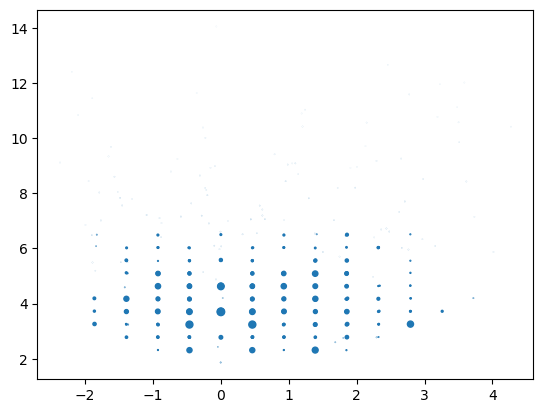

In [27]:
max_size = 30
plt.scatter(da_peaks.coords["Q_vec_rot"].values[:,1], da_peaks.coords["Q_vec_rot"].values[:,2], s=max_size*da_peaks.data.values/da_peaks.data.values.max())

Taking only strong peaks

TOD: Thrreshold in intensity normalized per time and incident spectra

In [28]:
threshold_strong = 0.3
da_peaks_strong = da_peaks[da_peaks.data > threshold_strong* da_peaks.data.max()]
da_peaks_strong

<scipp.DataArray>
Dimensions: Sizes[peaks:31, ]
Coordinates:
* Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-4.17359, 0.464146, 4.63775), (-3.24074, 0.926077, 5.09226)]
Data:
                            float64  [dimensionless]  (peaks)  [374.891, 320.137, ..., 116.971, 115.387]

## Estimation the size of the peaks in Q space: radial size and the transverse one

In [29]:
ind_peak = 0
l_q_peak_std = []
N_peak = da_peaks.size
l_xy = []
for ind_peak in range(N_peak):
    print(f"Progress {100*(ind_peak+1)/N_peak:.2f}%",end="\r")
    q_peak = da_peaks.coords["Q_vec_rot"][ind_peak]
    flag_peak = sc.norm(da_q_event_normalized.coords['Q_vec_rot']-q_peak)<sc.scalar(0.1, unit="1/Angstrom")
    da = da_q_event_normalized[flag_peak]
    
    np_q_vec = da.coords['Q_vec_rot'].values

    
    np_q_diff = numpy.abs((da.coords['Q_vec_rot']-q_peak).values)
    np_weight = numpy.expand_dims(da.data.values,axis=1)
    weight_sum = np_weight.sum()
    e_u = (q_peak/sc.norm(q_peak)).values

    np_q_vec_para = (np_q_vec *e_u).sum(axis=1)
    np_q_vec_perp = numpy.linalg.norm( np_q_vec -numpy.expand_dims(np_q_vec_para,axis=1)*numpy.expand_dims(e_u, axis=0), axis=1)

    
    if weight_sum <= 0.:
        continue

    # Weighted mean along radial direction (should be ~0 if centered well)
    mu_par = numpy.sum(np_weight[:,0] * np_q_vec_para) / weight_sum
    var_par = numpy.sum(np_weight[:,0] * (np_q_vec_para - mu_par)**2) / weight_sum
    sigma_par = numpy.sqrt(var_par)

    # Weighted mean of transverse radius
    var_perp = numpy.sum(np_weight[:,0] * (np_q_vec_perp)**2) / weight_sum
    sigma_perp = numpy.sqrt(var_perp)

    np_wavelength = da.coords['wavelength'].values
    wavelength = numpy.sum(np_weight[:,0] * np_wavelength) / weight_sum

    tth = numpy.sum(np_weight[:,0] * da.coords['two_theta'].to(unit="deg").values) / weight_sum
    da_hist = da.hist(norm_Q=101)
    l_xy.append((da_hist.coords["norm_Q"].values[:-1], da_hist.data.values))

    l_q_peak_std.append((mu_par, sigma_par, sigma_perp, wavelength,tth))
np_peak_param = numpy.array(l_q_peak_std,dtype=float).transpose()

Text(0.5, 1.0, 'Width of peak along the radial direction in Q')

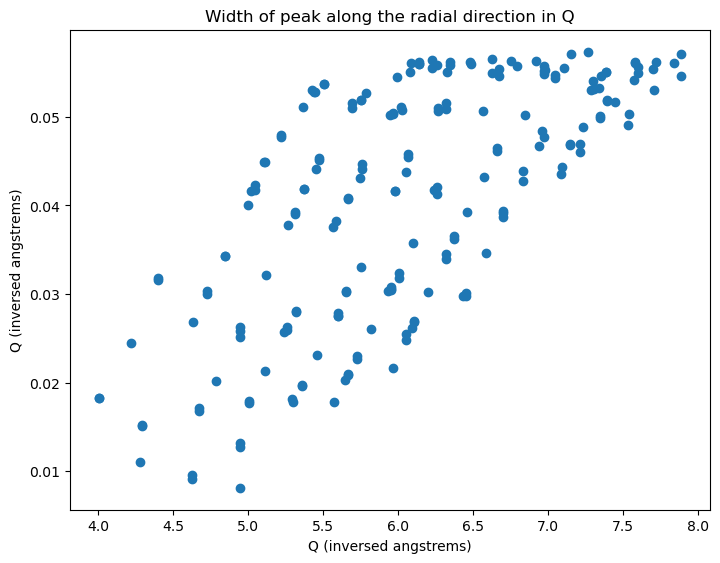

In [ ]:
n_max = 200
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_peak_param[0,:n_max], np_peak_param[1,:n_max])
ax.set_xlabel("Q (inversed angstrems)")
ax.set_ylabel("Delta Q (inversed angstrems)")
ax.set_title("Width of peak along the radial direction in Q")


Text(0.5, 1.0, 'Width of peak along the radial direction in Q')

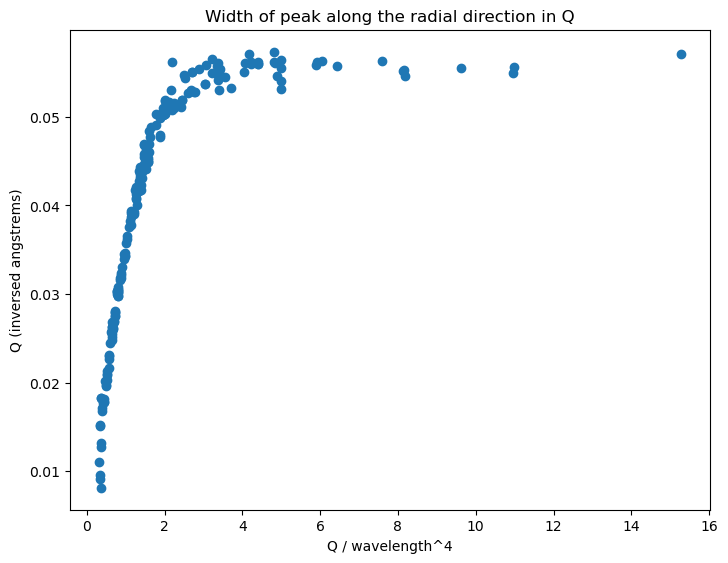

In [ ]:
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_peak_param[0,:n_max]*numpy.power(np_peak_param[3,:n_max],-4), np_peak_param[1,:n_max])
ax.set_xlabel("Q / wavelength^4")
ax.set_ylabel("delta Q (inversed angstrems)")
ax.set_title("Width of peak along the radial direction in Q")

Text(0.5, 1.0, 'Width of peak perpendicular to radial direction in Q')

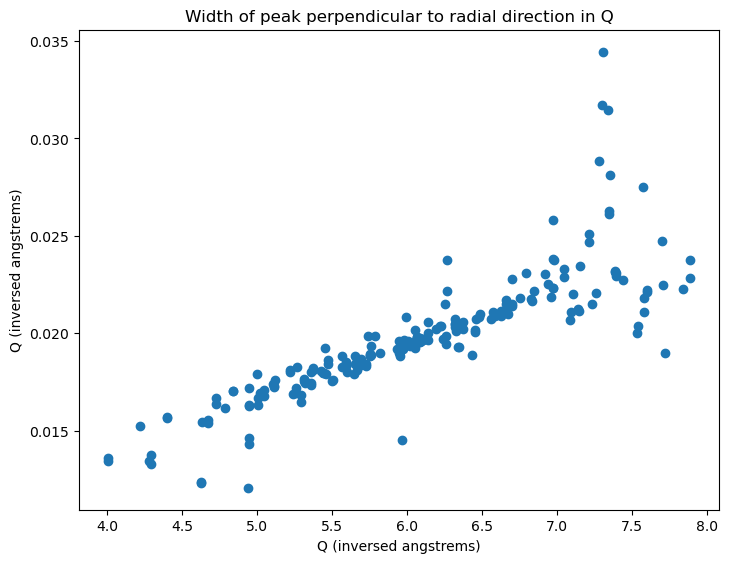

In [32]:
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_peak_param[0,:n_max], np_peak_param[2,:n_max])
ax.set_xlabel("Q (inversed angstrems)")
ax.set_ylabel("Q (inversed angstrems)")
ax.set_title("Width of peak perpendicular to radial direction in Q")

In [ ]:
# Look ion data with totally different wavelenth if wavelength dependence is here


Text(0, 0.5, 'Signal (arb.u.)')

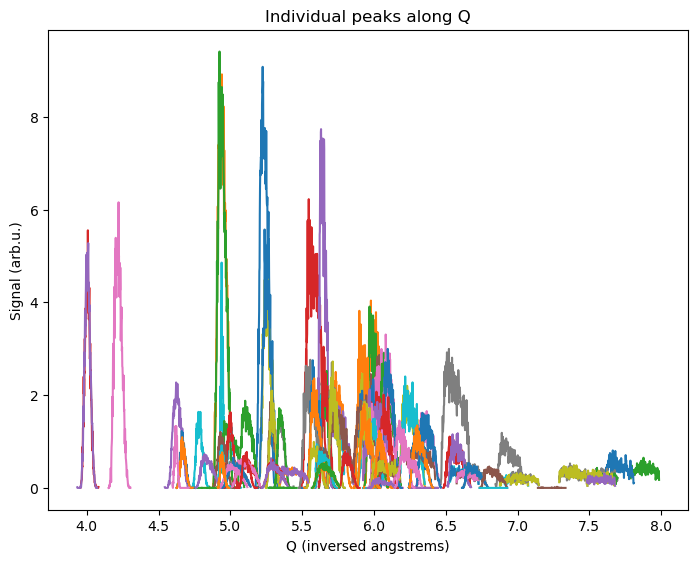

In [33]:
np_xy = numpy.array(l_xy)
np_xy.shape
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
for i in range(120):
    ax.plot(np_xy[i,0,:],np_xy[i,1,:])
ax.set_title("Individual peaks along Q")
ax.set_xlabel("Q (inversed angstrems)")
ax.set_ylabel("Signal (arb.u.)")


# Indexing
## UB matrix based on the strong peaks using provided unit cell parameters

In [34]:
import numpy as np
import scipy.optimize

def get_euleur_opt(
        cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
        Q_vec_rot, weight,
        euler_alpha, euler_beta, euler_gamma, graph_hkl=graph_hkl,
        relfine_unit_cell=False,singony='triclinic'):
    """
    Joint refinement of UB matrix and unknown hkl values.

    Parameters
    ----------
    B : (3,3) array
        Reciprocal lattice matrix.
    q_list : (N,3) array
        Measured Q vectors.
    hkl_init : (N,3) array or None
        Initial guess for hkl. If None, use fractional guess from B^-1 Q.

    Returns
    -------
    UB : (3,3) array
        Refined UB matrix.
    hkl : (N,3) array
        Refined fractional hkl values.
    """
    np_weight = np.asarray(weight) # values
    np_weight = np_weight / np.max(np_weight)

    ea_rad = euler_alpha.to(unit="rad", copy=False).value
    eb_rad = euler_beta.to(unit="rad", copy=False).value
    eg_rad = euler_gamma.to(unit="rad", copy=False).value


    h90 = sc.scalar(90., unit="deg")
    h120 = sc.scalar(120., unit="deg")

    def calc_b_matrix_by_x(x_cell):
        if singony.startswith('c'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,ha,ha,h90,h90,h90)
        elif singony.startswith('h'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hc = sc.scalar(x_cell[1], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,ha,hc,h90,h90,h120)
        elif singony.startswith('te'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hc = sc.scalar(x_cell[1], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,ha,hc,h90,h90,h90)
        elif singony.startswith('o'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hb = sc.scalar(x_cell[1], unit="angstrom")
            hc = sc.scalar(x_cell[2], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,hb,hc,h90,h90,h90)
        elif singony.startswith('m'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hb = sc.scalar(x_cell[1], unit="angstrom")
            hc = sc.scalar(x_cell[2], unit="angstrom")
            hbe = sc.scalar(x_cell[3], unit="deg")
            sc_b_matrix = graph_hkl['b_matrix'](ha,hb,hc,h90,hbe,h90)
        else:
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hb = sc.scalar(x_cell[1], unit="angstrom")
            hc = sc.scalar(x_cell[2], unit="angstrom")
            hal = sc.scalar(x_cell[3], unit="deg")
            hbe = sc.scalar(x_cell[4], unit="deg")
            hga = sc.scalar(x_cell[5], unit="deg")
            sc_b_matrix = graph_hkl['b_matrix'](ha,hb,hc,hal,hbe,hga)
        return sc_b_matrix

    cell_a_ang = cell_a.to(unit="angstrom", copy=False).value
    cell_b_ang = cell_b.to(unit="angstrom", copy=False).value
    cell_c_ang = cell_c.to(unit="angstrom", copy=False).value
    cell_alpha_deg = cell_alpha.to(unit="deg", copy=False).value
    cell_beta_deg = cell_beta.to(unit="deg", copy=False).value
    cell_gamma_deg = cell_gamma.to(unit="deg", copy=False).value

    if not relfine_unit_cell:
        sc_b_matrix = graph_hkl['b_matrix'](cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma)
        x0 = [ea_rad,eb_rad,eg_rad]
    elif singony.startswith('c'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,]
    elif singony.startswith('h') or singony.startswith('te'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,cell_c_ang]
    elif singony.startswith('o'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,cell_b_ang, cell_c_ang]
    elif singony.startswith('m'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,cell_b_ang, cell_c_ang, cell_beta_deg]
    else:
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang, cell_b_ang, cell_c_ang, cell_alpha_deg, cell_beta_deg, cell_gamma_deg]
        

    def calc_chi_sq(x):
        euleur_angles = x[:3]
        if relfine_unit_cell:
            sc_b_matrix = calc_b_matrix_by_x(x[3:])
        else:
            sc_b_matrix = graph_hkl['b_matrix'](cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma)
        sc_u = graph_hkl_inv["u_matrix"](
            sc.scalar(euleur_angles[0], unit="rad"),
            sc.scalar(euleur_angles[1], unit="rad"),
            sc.scalar(euleur_angles[2], unit="rad"),
            )
        sc_UB = graph_hkl["ub_matrix"](u_matrix=sc_u, b_matrix=sc_b_matrix)
        sc_hkl_int = graph_hkl["hkl_vec"](ub_matrix=sc_UB, Q_vec_rot=Q_vec_rot)
        sc_hkl_int.values = numpy.round(sc_hkl_int.values,0) 
        Q_vec_rot_ref = graph_hkl_inv["Q_vec_rot"](ub_matrix=sc_UB, hkl_vec=sc_hkl_int)
        Q_vec_rot_diff = Q_vec_rot_ref - Q_vec_rot
        chi_sq = (numpy.square(Q_vec_rot_diff.values)* numpy.expand_dims(np_weight, axis=1)).sum()
        return chi_sq


    res = scipy.optimize.minimize(calc_chi_sq, x0, method='BFGS')# Nelder-Mead
    # res = scipy.optimize.basinhopping(calc_chi_sq, x0)
    ea_opt = res.x[:3]
    if relfine_unit_cell:
        sc_b_matrix =calc_b_matrix_by_x(res.x[3:])
    else:
        ea_opt = res.x[:3]%(2.*numpy.pi)
    return (sc.scalar(ea_opt[0], unit="rad"), sc.scalar(ea_opt[1], unit="rad"), sc.scalar(ea_opt[2], unit="rad")), sc_b_matrix, res.fun

In [80]:
da_peaks_strong

<scipp.DataArray>
Dimensions: Sizes[peaks:31, ]
Coordinates:
  Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-4.17359, 0.464146, 4.63775), (-3.24074, 0.926077, 5.09226)]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0737936, -4.51856e-18, -4.51856e-18), , (0, 0.0737936, -4.51856e-18), , (0, 0, 0.0737936), )
  cell_a                    float64             [Å]  ()  13.5513
  cell_alpha                float64            [deg]  ()  90
  cell_b                    float64             [Å]  ()  13.5513
  cell_beta                 float64            [deg]  ()  90
  cell_c                    float64             [Å]  ()  13.5513
  cell_gamma                float64            [deg]  ()  90
  euler_alpha               float64            [rad]  ()  0.000154763
  euler_beta                float64            [rad]  ()  4.60572e-06
  euler_gamma               float64            [rad]  ()  6.28295
* h                         float64  [dimensionless]  (peaks)  [-7.98646, -7.98837, ..., -9.00131, -6.98923]
* h_reduced                 float64  [dimensionless]  (peaks)  [0.0135367, 0.0116344, ..., -0.00131284, 0.0107736]
  hkl_vec                   vector3  [dimensionless]  (peaks)  [(-7.98646, -0.000307576, 7.98818), (-7.98837, 0.999091, 6.99148), ..., (-9.00131, 1.00013, 10.0027), (-6.98923, 1.99586, 10.9832)]
* k                         float64  [dimensionless]  (peaks)  [-0.000307576, 0.999091, ..., 1.00013, 1.99586]
* k_reduced                 float64  [dimensionless]  (peaks)  [-0.000307576, -0.000909193, ..., 0.000131017, -0.00413607]
* l                         float64  [dimensionless]  (peaks)  [7.98818, 6.99148, ..., 10.0027, 10.9832]
* l_reduced                 float64  [dimensionless]  (peaks)  [-0.011816, -0.00852397, ..., 0.00268364, -0.0168087]
  u_matrix                rotation3  [dimensionless]  ()  (1-0.000115613i+2.29391e-06j+7.73816e-05k)
  ub_matrix               linear_transform3           [1/Å]  ()  ((0.0737936, -1.14206e-05, 3.37232e-07), , (1.14205e-05, 0.0737936, 1.70631e-05), , (-3.39873e-07, -1.7063e-05, 0.0737936), )
Data:
                            float64  [dimensionless]  (peaks)  [374.891, 320.137, ..., 116.971, 115.387]

In [35]:
# Given by User
cell_a = sc.scalar(14.04078, unit="angstrom")
cell_b = sc.scalar(14.04078, unit="angstrom")
cell_c = sc.scalar(14.04078, unit="angstrom")
cell_alpha = sc.scalar(90., unit="deg")
cell_beta = sc.scalar(90., unit="deg")
cell_gamma = sc.scalar(90., unit="deg")

# First estimation
euler_alpha = sc.scalar(1., unit="deg")
euler_beta = sc.scalar(1., unit="deg")
euler_gamma = sc.scalar(0., unit="deg")

# Only strong peaks used for refinement
factor = 0.3
da_peaks_strong = da_peaks[da_peaks.data > factor* da_peaks.data.max()]
da_peaks_strong


<scipp.DataArray>
Dimensions: Sizes[peaks:31, ]
Coordinates:
* Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-4.17359, 0.464146, 4.63775), (-3.24074, 0.926077, 5.09226)]
Data:
                            float64  [dimensionless]  (peaks)  [374.891, 320.137, ..., 116.971, 115.387]

In [36]:
print("# No refinement UB-matrix")
ea_opt, sc_b_matrix, chi_sq = get_euleur_opt(
    cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
    da_peaks_strong.coords["Q_vec_rot"], da_peaks_strong.data.values,
    euler_alpha, euler_beta, euler_gamma, graph_hkl=graph_hkl,
    relfine_unit_cell=False, singony='cubic')
euler_alpha, euler_beta, euler_gamma = ea_opt[0],ea_opt[1],ea_opt[2]
print(f"Optimized Euler angles (deg):\n {ea_opt[0].to(unit='deg').value:.2f} {ea_opt[1].to(unit='deg').value:.2f} {ea_opt[2].to(unit='deg').value:.2f}\n")
print(f"Chi-squared: {chi_sq:.4f}\n")

print("# UB-matrix is refined")
ea_opt, sc_b_matrix, chi_sq = get_euleur_opt(
    cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
    da_peaks_strong.coords["Q_vec_rot"], da_peaks_strong.data.values,
    euler_alpha, euler_beta, euler_gamma, graph_hkl=graph_hkl,
    relfine_unit_cell=True, singony='cubic')

print(f"Optimized Euler angles (deg):\n {ea_opt[0].to(unit='deg').value:.2f} {ea_opt[1].to(unit='deg').value:.2f} {ea_opt[2].to(unit='deg').value:.2f}\n")
print(f"Optimized B matrix:\n{sc_b_matrix.values}\n")
unit_cell = graph_ub_inv[("cell_a", "cell_b", "cell_c", "cell_alpha", "cell_beta", "cell_gamma")](sc_b_matrix)
ls_out=["Optimized unit cell:",]
l_label = ["a","b","c","alpha","beta","gamma"]
for ind, label in enumerate(l_label):
    ls_out.append(f"{label:>10} : {unit_cell[ind].value:} {unit_cell[ind].unit:}")
print("\n".join(ls_out)+"\n")

print(f"Chi-squared: {chi_sq:.4f}\n")


# No refinement UB-matrix
Optimized Euler angles (deg):
 0.01 0.00 359.99

Chi-squared: 0.5876

# UB-matrix is refined
Optimized Euler angles (deg):
 0.01 0.00 359.99

Optimized B matrix:
[[ 7.37936482e-02 -4.51855775e-18 -4.51855775e-18]
 [ 0.00000000e+00  7.37936482e-02 -4.51855775e-18]
 [ 0.00000000e+00  0.00000000e+00  7.37936482e-02]]

Optimized unit cell:
         a : 13.551301828396532 Å
         b : 13.551301828396532 Å
         c : 13.551301828396532 Å
     alpha : 90.0 deg
      beta : 90.0 deg
     gamma : 90.0 deg

Chi-squared: 0.0015



In [37]:
def remove_coords_in_da_except(da, *argv):
    names = numpy.copy(list(da.coords.keys()))
    for name in names:
        if not(name in argv):
            da.coords.pop(name)
    return

def remove_coords_in_da(da, *argv):
    for name in argv:
        if name in da.coords.keys():
            da.coords.pop(name)
    return

In [38]:
da_peaks.coords["cell_a"] = unit_cell[0]
da_peaks.coords["cell_b"] = unit_cell[1]
da_peaks.coords["cell_c"] = unit_cell[2]
da_peaks.coords["cell_alpha"] = unit_cell[3]
da_peaks.coords["cell_beta"] = unit_cell[4]
da_peaks.coords["cell_gamma"] = unit_cell[5]
da_peaks.coords["euler_alpha"] = ea_opt[0]
da_peaks.coords["euler_beta"] = ea_opt[1]
da_peaks.coords["euler_gamma"] = ea_opt[2]
remove_coords_in_da(da_peaks, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "u_matrix", "ub_matrix", "b_matrix")

da_peaks = da_peaks.transform_coords(("h","k","l","h_reduced","k_reduced","l_reduced"), graph=graph_hkl)  
da_peaks_strong = da_peaks[da_peaks.data > threshold_strong * da_peaks.data.max()]

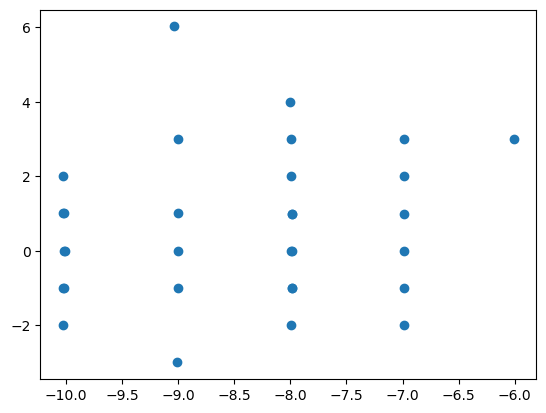

In [39]:
plt.scatter(da_peaks_strong.coords["h"].values, da_peaks_strong.coords["k"].values)

In [40]:
da_q_event_normalized.coords["cell_a"] = unit_cell[0]
da_q_event_normalized.coords["cell_b"] = unit_cell[1]
da_q_event_normalized.coords["cell_c"] = unit_cell[2]
da_q_event_normalized.coords["cell_alpha"] = unit_cell[3]
da_q_event_normalized.coords["cell_beta"] = unit_cell[4]
da_q_event_normalized.coords["cell_gamma"] = unit_cell[5]
da_q_event_normalized.coords["euler_alpha"] = da_peaks.coords["euler_alpha"]
da_q_event_normalized.coords["euler_beta"] = da_peaks.coords["euler_beta"]
da_q_event_normalized.coords["euler_gamma"] = da_peaks.coords["euler_gamma"]
remove_coords_in_da(da_q_event_normalized, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "u_matrix", "ub_matrix", "b_matrix")
da_q_event_normalized = da_q_event_normalized.transform_coords(("h","k","l","h_reduced","k_reduced","l_reduced", "norm_Q"), graph={**graph_hkl,**graph_qvec})  

## Visualisation to see the quality of indexing

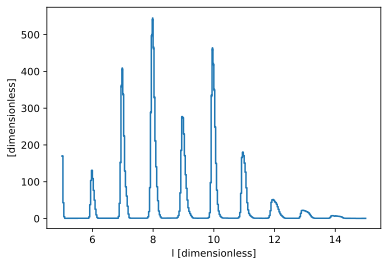

In [41]:
bin_h = sc.linspace(dim='h', start =-14,stop=-5,num=181,endpoint=True)
da_q_event_normalized.hist(h=bin_h).plot()
bin_k = sc.linspace(dim='k', start =-5,stop=8,num=341,endpoint=True)
da_q_event_normalized.hist(k=bin_k).plot()
bin_l = sc.linspace(dim='l', start =5,stop=15,num=341,endpoint=True)
da_q_event_normalized.hist(l=bin_l).plot()

In [42]:
da_q_event_normalized.coords["h"] = da_q_event_normalized.coords["h"].copy()
da_q_event_normalized.coords["k"] = da_q_event_normalized.coords["k"].copy()
da_q_event_normalized.coords["l"] = da_q_event_normalized.coords["l"].copy()
da_q_event_normalized.coords["h_reduced"] = da_q_event_normalized.coords["h_reduced"].copy()
da_q_event_normalized.coords["k_reduced"] = da_q_event_normalized.coords["k_reduced"].copy()
da_q_event_normalized.coords["l_reduced"] = da_q_event_normalized.coords["l_reduced"].copy()

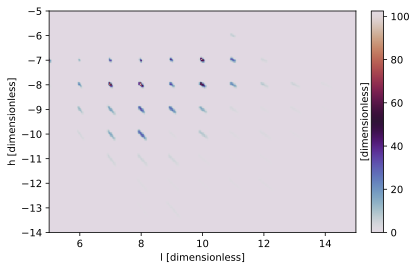

In [43]:
da_q_event_normalized.hist(h=bin_h, k=bin_k).plot(cmap='twilight')# norm="log"
da_q_event_normalized.hist(k=bin_k, l=bin_l).plot(cmap='twilight')# norm="log"
da_q_event_normalized.hist(h=bin_h, l=bin_l).plot(cmap='twilight')# norm="log"

In [44]:
bin_h_reduced = sc.linspace(dim='h_reduced', start =-0.5,stop=0.5,num=101,endpoint=True)
bin_k_reduced = sc.linspace(dim='k_reduced', start =-0.5,stop=0.5,num=101,endpoint=True)
bin_l_reduced = sc.linspace(dim='l_reduced', start =-0.5,stop=0.5,num=101,endpoint=True)

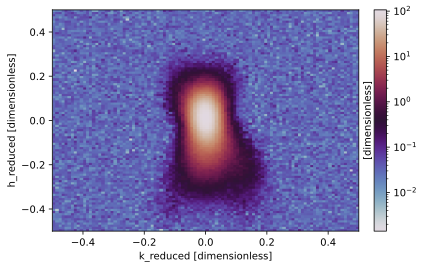

In [45]:
da_q_event_normalized.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(norm="log", cmap='twilight')

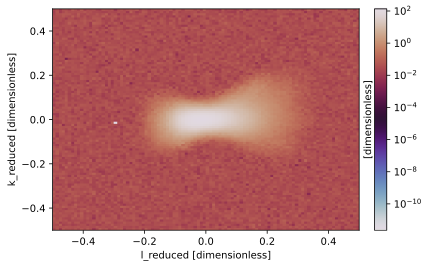

In [46]:
da_q_event_normalized.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(norm="log", cmap='twilight')

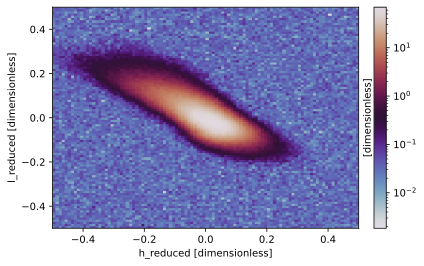

In [47]:
da_q_event_normalized.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(norm="log", cmap='twilight')

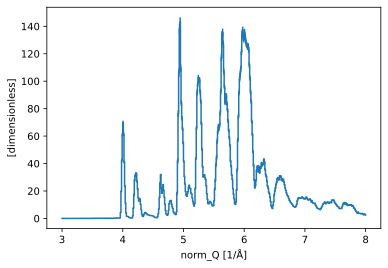

In [48]:
bin_q = sc.linspace(dim='norm_Q', start =3,stop=8,num=501,unit="1/Angstrom",endpoint=True)
da_q_event_normalized.hist(norm_Q=bin_q).plot()

## Correction on $\Delta t$, $\Delta L$, and sample offset

Correction is based on the events around strong peaks.


In [49]:
sc_flag = sc.zeros(dims=da_q_event_normalized.data.dims, shape = da_q_event_normalized.data.values.shape, dtype=bool) 
distance_treshold = sc.scalar(0.1, unit="1/Angstrom")
da_q_event_normalized = da_q_event_normalized.transform_coords(("Q_vec_rot",), graph=graph_qvec)
qvec = da_q_event_normalized.coords["Q_vec_rot"]
N= da_peaks_strong.coords["Q_vec_rot"].size
i=0
for q in da_peaks_strong.coords["Q_vec_rot"]:
    print(f"{100*(i+1)/N:.2f}%", end="\r")
    i+=1
    flag = (sc.norm(qvec-q) < distance_treshold)
    sc_flag = sc.logical_or(sc_flag, flag)

da_q_event_normalized_strong = da_q_event_normalized[sc_flag]
da_q_event_normalized_strong

<scipp.DataArray>
Dimensions: Sizes[event:195899, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00002, ..., 1, 1.00462]
  Ltotal                    float64              [m]  (event)  [155.5, 155.5, ..., 155.5, 155.505]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-3.71679, 0.0256409, 3.70655), ..., (-3.71582, 0.00644856, 3.69493), (-4.72519, -0.485092, 3.30629)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-3.71679, 0.0256409, 3.70655), ..., (-3.71582, 0.00644856, 3.69493), (-4.72519, -0.485092, 3.30629)]
  Qx                        float64           [1/Å]  (event)  [-3.73697, -3.71679, ..., -3.71582, -4.72519]
  Qy                        float64           [1/Å]  (event)  [0.00973955, 0.0256409, ..., 0.00644856, -0.485092]
  Qz                        float64           [1/Å]  (event)  [3.71059, 3.70655, ..., 3.69493, 3.30629]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0737936, -4.51856e-18, -4.51856e-18), , (0, 0.0737936, -4.51856e-18), , (0, 0, 0.0737936), )
  cell_a                    float64             [Å]  ()  13.5513
  cell_alpha                float64            [deg]  ()  90
  cell_b                    float64             [Å]  ()  13.5513
  cell_beta                 float64            [deg]  ()  90
  cell_c                    float64             [Å]  ()  13.5513
  cell_gamma                float64            [deg]  ()  90
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999996, -0.00689863, 0.00278296), ..., (0.999984, -0.00173541, 0.00563816), (0.937174, 0.0962111, 0.348863)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.56801, ..., 1.56516, 1.21444]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.00689863, ..., -0.00173541, 0.0962111]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  euler_alpha               float64            [rad]  ()  0.000154763
  euler_beta                float64            [rad]  ()  4.60572e-06
  euler_gamma               float64            [rad]  ()  6.28295
* h                         float64  [dimensionless]  (event)  [-8.05976, -8.01624, ..., -8.01415, -10.1913]
* h_reduced                 float64  [dimensionless]  (event)  [-0.059761, -0.0162427, ..., -0.01415, -0.191277]
  hkl_vec                   vector3  [dimensionless]  (event)  [(-8.05976, 0.0204027, 8.00281), (-8.01624, 0.0546933, 7.9941), ..., (-8.01415, 0.0133056, 7.96904), (-10.1913, -1.0463, 7.13057)]
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
* k                         float64  [dimensionless]  (event)  [0.0204027, 0.0546933, ..., 0.0133056, -1.0463]
* k_reduced                 float64  [dimensionless]  (event)  [0.0204027, 0.0546933, ..., 0.0133056, -0.0462972]
* l                         float64  [dimensionless]  (event)  [8.00281, 7.9941, ..., 7.96904, 7.13057]
* l_reduced                 float64  [dimensionless]  (event)  [0.00280912, -0.00589664, ..., -0.0309642, 0.130568]
* norm_Q                    float64           [1/Å]  (event)  [5.26626, 5.24916, ..., 5.24022, 5.78742]
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965996, -0.681097, 154.5), ..., (0.965984, -0.675933, 154.503), (0.903174, -0.577987, 154.846)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64          

In [50]:
da_q_event_normalized_strong = da_q_event_normalized_strong.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**graph_qvec, **graph_hkl})
# da_q_event_normalized_strong.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(cmap='twilight',)#norm="log", 

In [51]:
# da_q_event_normalized_strong.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(cmap='twilight',)# ,norm="log" 

In [52]:
# da_q_event_normalized_strong.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(cmap='twilight')# norm="log", 

In [53]:
def optimize_delta_t_delta_l(da):
    def calc_chi_sq(x, da, coeff):
        delta_t = x[0]
        delta_l = x[1]
        cell_a = x[2]
        ea = x[3]
        eb = x[4]
        eg = x[5]
        da.coords["delta_t"] = sc.scalar(delta_t, unit="s")
        da.coords["delta_L"] = sc.scalar(delta_l, unit="m")
        da.coords["cell_a"] = sc.scalar(cell_a, unit="Angstrom")
        da.coords["cell_b"] = sc.scalar(cell_a, unit="Angstrom")
        da.coords["cell_c"] = sc.scalar(cell_a, unit="Angstrom")
        da.coords["euler_alpha"] = sc.scalar(ea, unit="rad")
        da.coords["euler_beta"] = sc.scalar(eb, unit="rad")
        da.coords["euler_gamma"] = sc.scalar(eg, unit="rad")
        
        remove_coords_in_da(da, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "hkl_vec","Q_vec_rot","Q_vec","Qx","Qy","Qz","wavelength", "tof", "Ltotal", "Q", "u_matrix", "b_matrix", "ub_matrix")
        da2 = da.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**graph_hkl, **graph_qvec})
        nd_delta_hkl = numpy.array([
            da2.coords["h_reduced"].values,
            da2.coords["k_reduced"].values,
            da2.coords["l_reduced"].values,], dtype=float)    
          
        np_weight = da2.data.values
        chi_sq = numpy.square(np_weight*(numpy.abs(nd_delta_hkl-0.5)-0.5)/numpy.expand_dims(coeff, axis=1)).sum()
        return chi_sq
    x0 = [
        da.coords["delta_t"].to(unit="s").value, 
        da.coords["delta_L"].to(unit="m").value,
        da.coords["cell_a"].to(unit="Angstrom").value,
        da.coords["euler_alpha"].to(unit="rad").value,
        da.coords["euler_beta"].to(unit="rad").value,
        da.coords["euler_gamma"].to(unit="rad").value,
        ]
    
    coeff = numpy.array([da.coords["cell_a"].value, da.coords["cell_b"].value, da.coords["cell_c"].value], dtype=float)
    print("Original chi_sq", calc_chi_sq(x0, da, coeff))
    res = scipy.optimize.minimize(calc_chi_sq, x0, args=(da,coeff, ), method="BFGS")
    print(res)
    da.coords["delta_t"] = sc.scalar(res.x[0], unit="s")
    da.coords["delta_L"] = sc.scalar(res.x[1], unit="m")
    da.coords["cell_a"] = sc.scalar(res.x[2], unit="Angstrom")
    da.coords["cell_b"] = sc.scalar(res.x[2], unit="Angstrom")
    da.coords["cell_c"] = sc.scalar(res.x[2], unit="Angstrom")
    da.coords["euler_alpha"] = sc.scalar(res.x[3], unit="rad")
    da.coords["euler_beta"] = sc.scalar(res.x[4], unit="rad")
    da.coords["euler_gamma"] = sc.scalar(res.x[5], unit="rad")
    remove_coords_in_da(da, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "hkl_vec","Q_vec_rot","Q_vec","Qx","Qy","Qz","wavelength", "tof", "Ltotal", "Q", "u_matrix", "b_matrix", "ub_matrix")
    return

In [54]:
optimize_delta_t_delta_l(da_q_event_normalized_strong)

Original chi_sq 0.010680620968472967
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.009685078651887568
        x: [ 2.206e-03 -1.679e-02  1.374e+01  6.061e-05 -1.550e-04
             6.283e+00]
      nit: 9
      jac: [ 3.234e-04 -7.381e-08  1.159e-06  2.393e-06  2.893e-07
             5.377e-07]
 hess_inv: [[ 5.149e-04  9.924e-03 ...  2.006e-07  3.028e-07]
            [ 9.924e-03  1.187e+00 ...  3.974e-06  4.310e-06]
            ...
            [ 2.006e-07  3.974e-06 ...  2.384e-03 -1.825e-03]
            [ 3.028e-07  4.310e-06 ... -1.825e-03  2.755e-02]]
     nfev: 383
     njev: 53


In [55]:
da_q_event_normalized_strong = da_q_event_normalized_strong.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**graph_qvec, **graph_hkl})
da_q_event_normalized_strong


<scipp.DataArray>
Dimensions: Sizes[event:195899, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00002, ..., 1, 1.00462]
  Ltotal                    float64              [m]  (event)  [155.517, 155.517, ..., 155.517, 155.521]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.693, 0.00962497, 3.66694), (-3.6733, 0.0253409, 3.66318), ..., (-3.67235, 0.00637312, 3.65171), (-4.64998, -0.477372, 3.25367)]
  Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.693, 0.00962497, 3.66694), (-3.6733, 0.0253409, 3.66318), ..., (-3.67235, 0.00637312, 3.65171), (-4.64998, -0.477372, 3.25367)]
  Qx                        float64           [1/Å]  (event)  [-3.693, -3.6733, ..., -3.67235, -4.64998]
  Qy                        float64           [1/Å]  (event)  [0.00962497, 0.0253409, ..., 0.00637312, -0.477372]
  Qz                        float64           [1/Å]  (event)  [3.66694, 3.66318, ..., 3.65171, 3.25367]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0727606, -4.4553e-18, -4.4553e-18), , (0, 0.0727606, -4.4553e-18), , (0, 0, 0.0727606), )
  cell_a                    float64             [Å]  ()  13.7437
  cell_alpha                float64            [deg]  ()  90
  cell_b                    float64             [Å]  ()  13.7437
  cell_beta                 float64            [deg]  ()  90
  cell_c                    float64             [Å]  ()  13.7437
  cell_gamma                float64            [deg]  ()  90
  delta_L                   float64              [m]  ()  -0.0167873
  delta_t                   float64              [s]  ()  0.00220606
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999996, -0.00689863, 0.00278296), ..., (0.999984, -0.00173541, 0.00563816), (0.937174, 0.0962111, 0.348863)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.56801, ..., 1.56516, 1.21444]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.00689863, ..., -0.00173541, 0.0962111]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  euler_alpha               float64            [rad]  ()  6.06134e-05
  euler_beta                float64            [rad]  ()  -0.000155014
  euler_gamma               float64            [rad]  ()  6.28307
  h                         float64  [dimensionless]  (event)  [-8.07675, -8.03366, ..., -8.03158, -10.1702]
* h_reduced                 float64  [dimensionless]  (event)  [-0.0767532, -0.0336558, ..., -0.0315841, -0.170237]
  hkl_vec                   vector3  [dimensionless]  (event)  [(-8.07675, 0.0205911, 8.02224), (-8.03366, 0.054966, 8.01401), ..., (-8.03158, 0.0134793, 7.98892), (-10.1702, -1.04442, 7.11845)]
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
  k                         float64  [dimensionless]  (event)  [0.0205911, 0.054966, ..., 0.0134793, -1.04442]
* k_reduced                 float64  [dimensionless]  (event)  [0.0205911, 0.054966, ..., 0.0134793, -0.0444206]
  l                         float64  [dimensionless]  (event)  [8.02224, 8.01401, ..., 7.98892, 7.11845]
* l_reduced                 float64  [dimensionless]  (event)  [0.0222374, 0.0140148, ..., -0.0110812, 0.118452]
* norm_Q                    float64           [1/Å]  (event)  [5.26626, 5.24916, ..., 5.24022, 5.78742]
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965996, -0.681097, 154.5), ..., (0.965984, -0.675933, 154.503), (0.903174, -0.577987, 154.846)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64

In [56]:
# da_q_event_normalized_strong.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(cmap='twilight',)#norm="log", 

In [57]:
# da_q_event_normalized_strong.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(cmap='twilight',)#norm="log", 

In [58]:
# da_q_event_normalized_strong.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(cmap='twilight',)#norm="log", 

In [59]:
da_q_event_normalized.coords["delta_t"] = da_q_event_normalized_strong.coords["delta_t"]
da_q_event_normalized.coords["delta_L"] = da_q_event_normalized_strong.coords["delta_L"]
da_q_event_normalized.coords["cell_a"] = da_q_event_normalized_strong.coords["cell_a"]
da_q_event_normalized.coords["cell_b"] = da_q_event_normalized_strong.coords["cell_b"]
da_q_event_normalized.coords["cell_c"] = da_q_event_normalized_strong.coords["cell_c"]
da_q_event_normalized.coords["cell_alpha"] = da_q_event_normalized_strong.coords["cell_alpha"]
da_q_event_normalized.coords["cell_beta"] = da_q_event_normalized_strong.coords["cell_beta"]
da_q_event_normalized.coords["cell_gamma"] = da_q_event_normalized_strong.coords["cell_gamma"]
da_q_event_normalized.coords["euler_alpha"] = da_q_event_normalized_strong.coords["euler_alpha"]
da_q_event_normalized.coords["euler_beta"] = da_q_event_normalized_strong.coords["euler_beta"]
da_q_event_normalized.coords["euler_gamma"] = da_q_event_normalized_strong.coords["euler_gamma"]
remove_coords_in_da(da_q_event_normalized, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "hkl_vec","Q_vec_rot","Q_vec","Qx","Qy","Qz","wavelength", "tof", "Ltotal", "Q", "u_matrix", "b_matrix", "ub_matrix")
da_q_event_normalized = da_q_event_normalized.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**graph_qvec, **graph_hkl})
da_q_event_normalized

<scipp.DataArray>
Dimensions: Sizes[event:1744654, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00573, ..., 1.0211, 1.09208]
  Ltotal                    float64              [m]  (event)  [155.517, 155.522, ..., 155.538, 155.609]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.693, 0.00962497, 3.66694), (-4.5454, 0.48725, 4.61013), ..., (-4.07163, 0.918999, 2.74822), (-4.07076, 1.82617, 3.68294)]
  Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.693, 0.00962497, 3.66694), (-4.5454, 0.48725, 4.61013), ..., (-4.07163, 0.918999, 2.74822), (-4.07076, 1.82617, 3.68294)]
  Qx                        float64           [1/Å]  (event)  [-3.693, -4.5454, ..., -4.07163, -4.07076]
  Qy                        float64           [1/Å]  (event)  [0.00962497, 0.48725, ..., 0.918999, 1.82617]
  Qz                        float64           [1/Å]  (event)  [3.66694, 4.61013, ..., 2.74822, 3.68294]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0727606, -4.4553e-18, -4.4553e-18), , (0, 0.0727606, -4.4553e-18), , (0, 0, 0.0727606), )
  cell_a                    float64             [Å]  ()  13.7437
  cell_alpha                float64            [deg]  ()  90
  cell_b                    float64             [Å]  ()  13.7437
  cell_beta                 float64            [deg]  ()  90
  cell_c                    float64             [Å]  ()  13.7437
  cell_gamma                float64            [deg]  ()  90
  delta_L                   float64              [m]  ()  -0.0167873
  delta_t                   float64              [s]  ()  0.00220606
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  euler_alpha               float64            [rad]  ()  6.06134e-05
  euler_beta                float64            [rad]  ()  -0.000155014
  euler_gamma               float64            [rad]  ()  6.28307
  h                         float64  [dimensionless]  (event)  [-8.07675, -9.94089, ..., -8.90514, -8.90279]
* h_reduced                 float64  [dimensionless]  (event)  [-0.0767532, 0.0591112, ..., 0.0948565, 0.0972058]
  hkl_vec                   vector3  [dimensionless]  (event)  [(-8.07675, 0.0205911, 8.02224), (-9.94089, 1.06521, 10.0858), ..., (-8.90514, 2.01003, 6.01303), (-8.90279, 3.99412, 8.05785)]
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
  k                         float64  [dimensionless]  (event)  [0.0205911, 1.06521, ..., 2.01003, 3.99412]
* k_reduced                 float64  [dimensionless]  (event)  [0.0205911, 0.0652057, ..., 0.0100252, -0.00588153]
  l                         float64  [dimensionless]  (event)  [8.02224, 10.0858, ..., 6.01303, 8.05785]
* l_reduced                 float64  [dimensionless]  (event)  [0.0222374, 0.0857652, ..., 0.0130273, 0.0578485]
* norm_Q                    float64           [1/Å]  (event)  [5.26626, 6.58852, ..., 5.07106, 5.8704]
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965964, -0.78139, 154.489), ..., (0.880968, -0.880713, 154.901), (0.944357, -1.1131, 154.704)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  samp

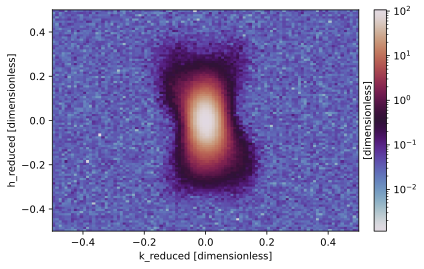

In [60]:
da_q_event_normalized.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(norm="log", cmap='twilight',)

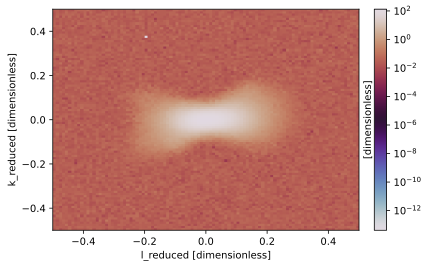

In [61]:
da_q_event_normalized.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(norm="log", cmap='twilight',)

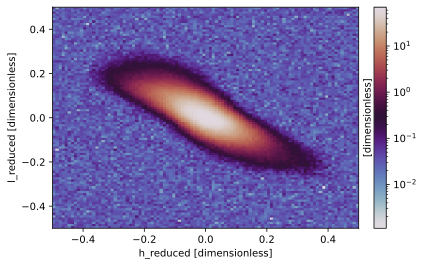

In [62]:
da_q_event_normalized.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(norm="log", cmap='twilight',)

## Shape of the diffraction peak
...

# Peak integration

Model Fsq (used in McStas simulation)


In [63]:
def load_fsq(f_name:str):
    with open(f_name, 'r') as fid:
        l_content = fid.readlines()
    l_content = [hh for hh in l_content if not hh.startswith("#")]
    l_hkl, l_fsq = [], []
    for line in l_content:
        l_hh = line.strip().split()
        l_hkl.append((int(l_hh[0]), int(l_hh[1]), int(l_hh[2])))
        l_fsq.append(l_hh[-1])
    np_hkl = numpy.array(l_hkl, dtype=int).transpose()
    np_fsq = numpy.array(l_fsq, dtype = float)
    return np_hkl, np_fsq
f_name_fsq = "C60_tetra.hkl"
np_hkl_model, np_fsq_model = load_fsq(f_name_fsq)

Naive integration

In [64]:

def naive_integration(da, integration_box, scale:float=1.):
    ls_out = ["# Naive integration\n"]
    da = da.transform_coords(("two_theta","h","k","l"), graph={**graph_qvec,**graph_hkl})
    np_hkl = numpy.array([da.coords["h"].values, da.coords["k"].values, da.coords["l"].values], dtype=float)
    np_hkl = numpy.unique(numpy.round(np_hkl,0).astype(int),axis=1)


    l_fsq_exp = []
    l_fsq_mod = []
    l_hkl = []
    l_ratio = []
    l_wavelength = []
    l_tth = []
    N_hkl = np_hkl.shape[1]
    i_hkl = 0
    for hkl in np_hkl.transpose():
        i_hkl += 1
        print(f"Progress: {100*i_hkl/N_hkl:.2f}",end="\r")
        flag_h = sc.abs(da.coords["h"]-hkl[0]) < integration_box[0]
        flag_k = sc.abs(da.coords["k"]-hkl[1]) < integration_box[1]
        flag_l = sc.abs(da.coords["l"]-hkl[2]) < integration_box[2]
        flag_hkl = sc.logical_and(flag_h, sc.logical_and(flag_k, flag_l))
        da_one_hkl = da[flag_hkl]
        np_wavelength = da_one_hkl.coords['wavelength'].values
        wavelength = numpy.mean(np_wavelength)
        np_tth = da_one_hkl.coords['two_theta'].values
        tth = numpy.mean(np_tth)
        sin_sq = numpy.square(numpy.sin(0.5*tth))
        val = sc.sum(da_one_hkl.data)
        iint = val.value
        siint = numpy.sqrt(val.variance)
        fsq_exp = scale * iint * sin_sq / (numpy.power(wavelength,4))
        flag_hkl_model = (np_hkl_model == numpy.expand_dims(hkl,axis=1)).prod(axis=0).astype(bool)
        if flag_hkl_model.sum() != 1:
            print("Reflection ", hkl, " is not found")
        else:
            fsq_mod = np_fsq_model[flag_hkl_model][0]
            ratio = fsq_mod/fsq_exp
            l_fsq_exp.append(fsq_exp)
            l_fsq_mod.append(fsq_mod)
            l_hkl.append(hkl)
            l_ratio.append(ratio)
            l_wavelength.append((wavelength, numpy.std(np_wavelength)))
            l_tth.append((numpy.degrees(tth), numpy.degrees(numpy.std(np_tth))))
    scale_new = scale * numpy.median(l_ratio)
    print(f"Scale should be around {scale_new:}")
    np_fsq_exp = numpy.array(l_fsq_exp)# *scale_new/scale
    np_fsq_mod = numpy.array(l_fsq_mod, dtype=float)
    np_wavelength = numpy.array(l_wavelength, dtype=float)

    np_tth = numpy.array(l_tth, dtype=float)
    np_hkl_int = numpy.array(l_hkl, dtype=int).transpose()
    np_diff_fsq_norm = numpy.abs((np_fsq_exp-np_fsq_mod)/np_fsq_mod)
    ls_out.append("  h   k   l Fsq_exp Fsq_mod      RF2 Wavelength  STD    2Theta       STD")
    ls_out_bad = []
    for hkl, hh1, hh2, hh3, hh4, hh5 in zip(np_hkl_int.transpose(), np_fsq_exp, np_fsq_mod, np_diff_fsq_norm, np_wavelength, np_tth):
        s_common = f"{hkl[0]:3} {hkl[1]:3} {hkl[2]:3} {hh1:7.2f} {hh2:7.2f} {hh3*100:7.2f}% {hh4[0]:7.5f} {hh4[1]:7.5f} {hh5[0]:9.2f} {hh5[1]:9.2f}"
        if hh3 > 0.1:
            ls_out_bad.append(s_common+"  ! Bad integration")
        else:
            ls_out.append(s_common)
    ls_out.extend(ls_out_bad)
    rf2 = np_diff_fsq_norm.mean()*100
    rf2_without_bad = np_diff_fsq_norm[np_diff_fsq_norm<=0.1].mean()*100
    ls_out.append(f"\n Agreement factor RF2 is {rf2:.2f}% (all)")
    ls_out.append(f"                         {rf2_without_bad:.2f}% (without bad)")
    print("\n".join(ls_out))
    return np_hkl_int, np_fsq_exp, np_fsq_mod, np_wavelength, np_tth
    


Scale should be around 33.69922245254776
# Naive integration

  h   k   l Fsq_exp Fsq_mod      RF2 Wavelength  STD    2Theta       STD
-10  -2   8  565.33  585.17    3.39% 1.30659 0.01249     76.22      0.33
-10  -1   7  611.55  658.02    7.06% 1.28091 0.01303     69.72      0.30
-10  -1   8  634.03  652.23    2.79% 1.33004 0.01294     77.03      0.33
-10   0   8  478.95  481.71    0.57% 1.33930 0.01298     77.36      0.33
-10   0  10  895.38  924.43    3.14% 1.37358 0.01175     90.06      0.31
-10   1   7  617.59  658.02    6.15% 1.28026 0.01313     69.71      0.29
-10   1   8  626.50  652.23    3.94% 1.33014 0.01293     77.04      0.34
-10   2   8  552.30  585.17    5.62% 1.30710 0.01257     76.23      0.33
 -9  -3   9  588.51  587.04    0.25% 1.44442 0.01302     87.05      0.31
 -9  -1  10  422.05  405.32    4.13% 1.50676 0.01254     95.70      0.35
 -9   0   8  836.42  843.32    0.82% 1.51330 0.01421     83.30      0.37
 -9   1  10  417.46  405.32    3.00% 1.50669 0.01241     95.69

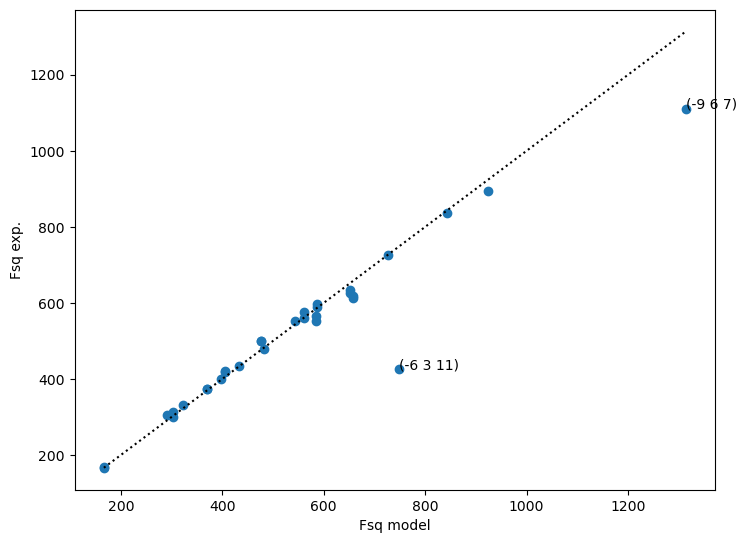

In [65]:
da = da_q_event_normalized_strong
scale = 33.6992238296537
integration_box = [0.5, 0.5, 0.5]
np_hkl_int, np_fsq_exp, np_fsq_mod, np_wavelength, np_tth = naive_integration(da, integration_box, scale=scale)

fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_fsq_mod, np_fsq_exp)
ax.plot([np_fsq_mod.min(),np_fsq_mod.max(),],[np_fsq_mod.min(),np_fsq_mod.max(),], ":k")
ax.set_xlabel("Fsq model")
ax.set_ylabel("Fsq exp.")
np_diff_fsq_norm = numpy.abs((np_fsq_mod-np_fsq_exp)/np_fsq_mod)
np_flag_bad = np_diff_fsq_norm>0.1
for hkl, fsq_mod, fsq_exp, in zip(np_hkl_int[:,np_flag_bad].transpose(),np_fsq_mod[np_flag_bad],np_fsq_exp[np_flag_bad]):
    ax.text(fsq_mod, fsq_exp, f"({hkl[0]:} {hkl[1]:} {hkl[2]:})")


In [66]:
da = da_q_event_normalized
integration_box = [0.5, 0.5, 0.5]
np_hkl_int, np_fsq_exp, np_fsq_mod, np_wavelength, np_tth = naive_integration(da, integration_box, scale=scale)





Reflection  [-21   0  17]  is not found
Reflection  [-21   0  19]  is not found
Reflection  [-21   0  21]  is not found
Reflection  [-21   0  23]  is not found
Reflection  [-21   0  25]  is not found
Reflection  [-21   0  27]  is not found
Reflection  [-20   0  13]  is not found
Reflection  [-20   0  15]  is not found
Reflection  [-20   0  17]  is not found
Reflection  [-20   0  19]  is not found
Reflection  [-20   0  21]  is not found
Reflection  [-20   0  23]  is not found
Reflection  [-20   0  25]  is not found
Reflection  [-20   0  27]  is not found
Reflection  [-20   0  29]  is not found
Reflection  [-19   0  11]  is not found
Reflection  [-19   0  13]  is not found
Reflection  [-19   0  15]  is not found
Reflection  [-19   0  17]  is not found
Reflection  [-19   0  19]  is not found
Reflection  [-19   0  21]  is not found
Reflection  [-19   0  23]  is not found
Reflection  [-19   0  25]  is not found
Reflection  [-19   0  27]  is not found
Reflection  [-19   0  29]  is not found


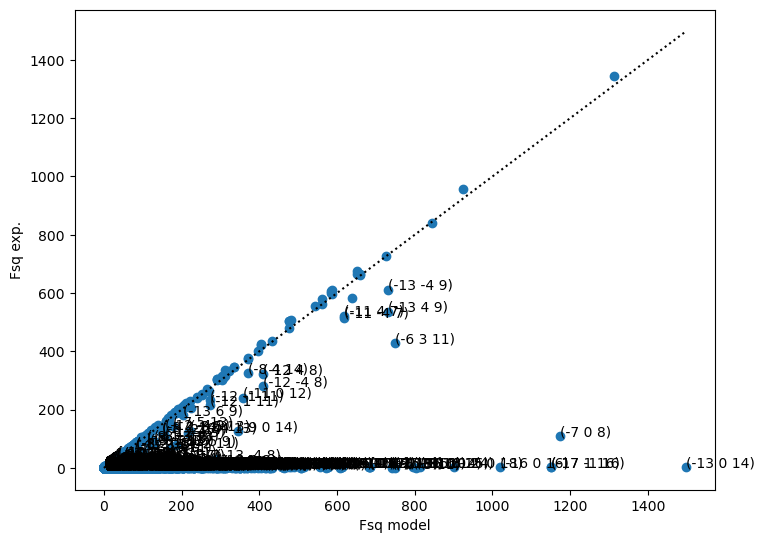

In [67]:
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
# scale = 0.062
np_fsq_exp_sc = np_fsq_exp # * scale
ax.scatter(np_fsq_mod, np_fsq_exp_sc)
ax.plot([np_fsq_mod.min(),np_fsq_mod.max(),],[np_fsq_mod.min(),np_fsq_mod.max(),], ":k")
ax.set_xlabel("Fsq model")
ax.set_ylabel("Fsq exp.")
np_diff_fsq_norm = numpy.abs((np_fsq_mod-np_fsq_exp_sc)/np_fsq_mod)
np_flag_bad = np_diff_fsq_norm>0.1
for hkl, fsq_mod, fsq_exp, in zip(np_hkl_int[:,np_flag_bad].transpose(),np_fsq_mod[np_flag_bad],np_fsq_exp_sc[np_flag_bad]):
    ax.text(fsq_mod, fsq_exp, f"({hkl[0]:} {hkl[1]:} {hkl[2]:})")

In [81]:

plopp.scatter3d(da_q_event_normalized, pos='hkl_vec', cbar=True, size=0.0001, opacity=0.5)

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

# Output
Export results in formats compatible with refinement tools
## EasyDiffraction
...
## FullProf 
...
## Mag2Pol
...


In [ ]:
https://scipp.github.io/user-guide/groupby.html

Probably use it for integration: asign area of detectors for indexation and integrate further

In [ ]:
# Synthetic example with 3 peaks
rng = numpy.random.default_rng(0)

centers = numpy.array([
    [0.2, 0.1, 0.0],
    [0.8, -0.2, 0.3],
    [-0.4, 0.5, -0.1]
])

q_events = []
weights = []

for c in centers:
    pts = c + 0.03 * rng.standard_normal((800, 3))
    q_events.append(pts)
    weights.append(rng.uniform(0.5, 1.5, size=800))

q_events = numpy.vstack(q_events)
weights = numpy.concatenate(weights)

peaks, intensities = find_multiple_peaks(q_events, weights, max_peaks=3)

print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)


Detected peaks:
 [[-0.40223781  0.50135126 -0.09777805]
 [ 0.19728945  0.10152996 -0.00128652]
 [ 0.79953506 -0.19851627  0.30079823]]
Intensities:
 [795.38879818 794.77672387 780.81633989]


In [ ]:
Detected peaks:
 [[-0.40223781  0.50135126 -0.09777805]
 [ 0.19728945  0.10152996 -0.00128652]]
Intensities:
 [795.38879818 794.77672387]

In [60]:
import numpy as np
from scipy.spatial import KDTree

def reduce_kspace_events(
    k_points,
    weights,
    target_count=None,
    distance_threshold=None,
):
    """
    Reduce weighted events in k-space by parallel merging of nearest neighbors.

    Parameters
    ----------
    k_points : (N, d) array
        Event coordinates in k-space.
    weights : (N,) array
        Event weights.
    target_count : int or None
        Stop when number of events <= target_count.
    distance_threshold : float or None
        Stop when all nearest-neighbor distances exceed this value.

    Returns
    -------
    k_points : (M, d) array
        Reduced coordinates.
    weights : (M,) array
        Reduced weights.
    """

    k_list = [np.array(k) for k in k_points]
    w_list = [float(w) for w in weights]

    while True:

        N = len(k_list)
        if target_count is not None and N <= target_count:
            break

        # Build KDTree
        tree = KDTree(np.vstack(k_list))

        # Query nearest neighbor for each point
        dists, idxs = tree.query(np.vstack(k_list), k=2)
        nn_dist = dists[:, 1]
        nn_idx = idxs[:, 1]

        # Check distance threshold stopping condition
        if distance_threshold is not None:
            if np.all(nn_dist > distance_threshold):
                break

        # Build list of candidate pairs (i, j, dist)
        pairs = [(i, nn_idx[i], nn_dist[i]) for i in range(N)]
        # Sort by distance
        pairs.sort(key=lambda x: x[2])

        merged = set()
        new_k = []
        new_w = []

        # Parallel merging: take smallest non-overlapping pairs
        for i, j, d in pairs:
            if i in merged or j in merged:
                continue
            if distance_threshold is not None and d > distance_threshold:
                break

            # Merge i and j
            wi, wj = w_list[i], w_list[j]
            ki, kj = k_list[i], k_list[j]

            w_new = wi + wj
            k_new = (wi * ki + wj * kj) / w_new

            new_k.append(k_new)
            new_w.append(w_new)

            merged.add(i)
            merged.add(j)

        # Add all unmerged points
        for idx in range(N):
            if idx not in merged:
                new_k.append(k_list[idx])
                new_w.append(w_list[idx])

        k_list = new_k
        w_list = new_w

        # If no merges happened, stop
        if len(merged) == 0:
            break

    return np.vstack(k_list), np.array(w_list)




In [82]:

# Example: 2000 events in 3D
N = 2000000
k = np.random.randn(N, 1)
w = np.random.rand(N)

k_red, w_red = reduce_kspace_events(
    k, w,
    target_count=300,
    distance_threshold=0.05
)

print(k_red.shape, w_red.shape)

(251, 1) (251,)


In [69]:
k_red.min(), k_red.max()

(np.float64(-5.00290179287727), np.float64(4.846386584872402))

	◦ max_seeds: e.g. 10^3–10^4 seeds instead of all events.
	◦ radius_factor: trade off accuracy vs speed (smaller → fewer neighbors).
	◦ Region cuts in Q before building the tree.

In [65]:
k_red, w_red = reduce_kspace_events(
    k_red, w_red,
    target_count=300,
    distance_threshold=0.05
)

print(k_red.shape, w_red.shape)

(311945, 3) (311945,)


In [42]:
peaks, intensities = find_multiple_peaks_accel(np_qxyz, np_weight, max_peaks=30)
print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)

Detected peaks:
 [[-3.92649271e+00  2.61808567e+00  3.05391068e+00]
 [-3.97110164e+00  4.79660476e-04  3.53034168e+00]
 [-4.39486743e+00  2.41258324e-04  4.39557838e+00]
 [-4.38585199e+00  4.38897385e-01  3.06934795e+00]
 [-4.38452034e+00 -4.38029663e-01  3.06866515e+00]
 [-4.39194116e+00 -4.38768797e-01  3.51312464e+00]
 [-4.39168354e+00  4.39483301e-01  3.51356598e+00]
 [-4.38859356e+00 -8.77528731e-01  3.51109226e+00]
 [-4.38843969e+00  8.78115136e-01  3.51094926e+00]
 [-3.96448840e+00  1.32177857e+00  3.96448869e+00]
 [-3.96550127e+00 -1.32140118e+00  3.96529143e+00]
 [-3.54442261e+00  1.39416088e-04  3.54473649e+00]
 [-4.39274170e+00  1.76778195e-04  3.51325422e+00]
 [-3.11342029e+00  1.78627389e-04  3.55759324e+00]
 [-3.54266384e+00  4.43187977e-01  3.09994620e+00]
 [-3.54291908e+00 -4.42564082e-01  3.09960669e+00]
 [-4.80311866e+00  3.20603467e-04  3.49490500e+00]
 [-3.09810286e+00  1.32813440e+00  2.21277236e+00]
 [-3.96263702e+00 -1.32036002e+00  3.52271887e+00]
 [-3.96205846e